In [1]:
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import Tuple, List, Dict
from tqdm import tqdm
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
import numpy as np
import numpy as np
import random
import json
from pathlib import Path
from typing import Dict, List, Tuple
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Dict, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from pathlib import Path
import os

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, print_raster_stats,gmm_no_manila_path_box_load_all_flood_maps,
    load_all_rainfall_scenarios, get_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps,
    get_raster_stats, load_manila_mask, gmm_path_load_all_flood_maps
)

from data_preprocessing import (normalize_dem, normalize_infiltration, normalize_landuse, handle_nodata )

from flood_maps import (reconstruct_map_from_patches, categorize_all_flood_maps_patch, visualize_all_categorized_maps)

from quadrant import ( stack_spatial_inputs, split_into_quadrants, build_train_test_split, extract_spatial_patches, get_quadrant_patch_indices, visualize_quadrant_split )

from vit import ViT

from training import FloodPatchDataset, train_kfold

FLOOD_CLASSES_VEC = {
    0: {
        'name': 'No Flood',
        'range': (0.0, 0.15),
        'color': '#FFFFFF'  # White
    },
    1: {
        'name': 'Light',
        'range': (0.15, 0.24),
        'color': '#C6DBEF'  # Light blue
    },
    2: {
        'name': 'Moderate',
        'range': (0.24, 0.46),
        'color': '#6BAED6'  # Medium blue
    },
    3: {
        'name': 'Heavy',
        'range': (0.46, 0.68),
        'color': '#2171B5'  # Deep blue
    },
    4: {
        'name': 'Extreme',
        'range': (0.68, float('inf')),
        'color': '#08306B'  # Dark navy
    }
}


RANDOM_SEED = 42
NUM_SCENARIO = 50
PATCH_SIZE = 4

In [2]:
repo_root = os.getcwd()
gmm_path = os.path.join(repo_root, "COP-30m-GMM")
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rainfall_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     466.3908
Mean value:    42.0699
Std dev:       69.0678
Valid pixels:  1,377,000 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.4818
Std dev:       0.9485
Valid pixels:  1,377,000 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.9338
Std dev:       2.5013
Valid pixels:  1,377,000 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

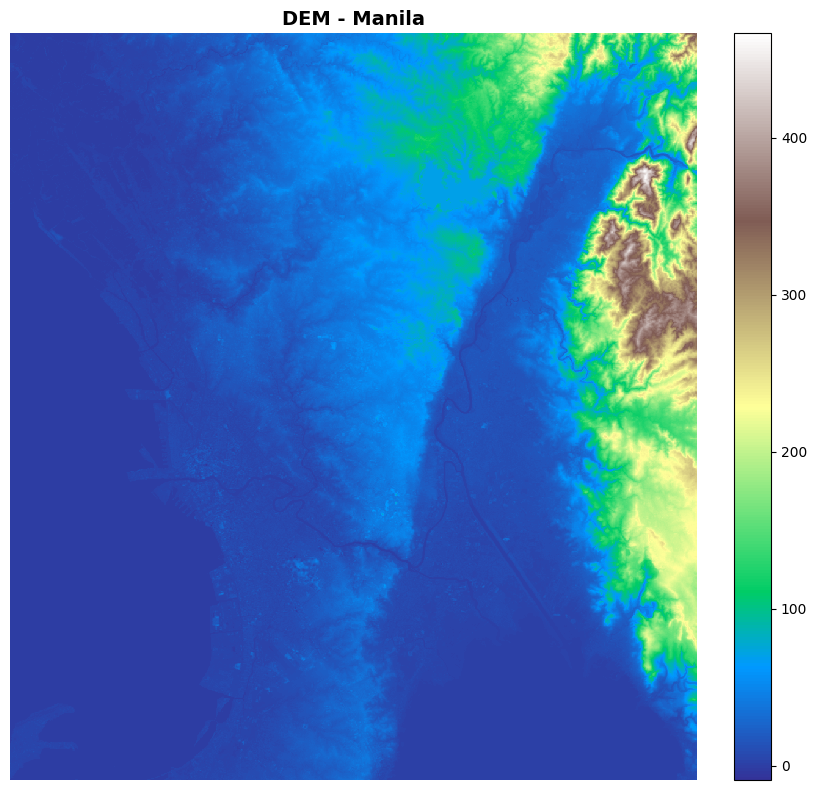

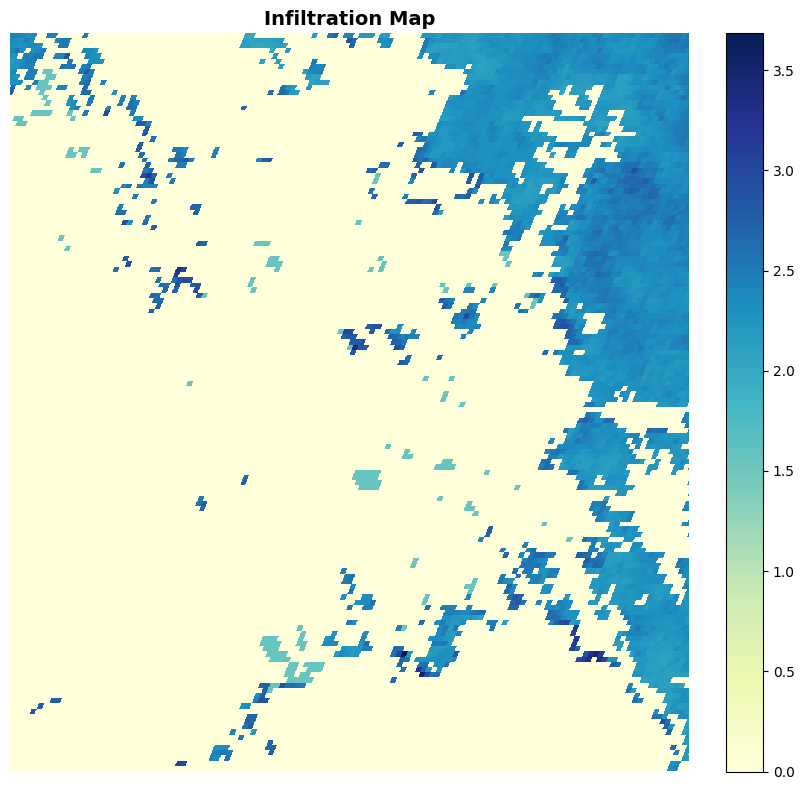

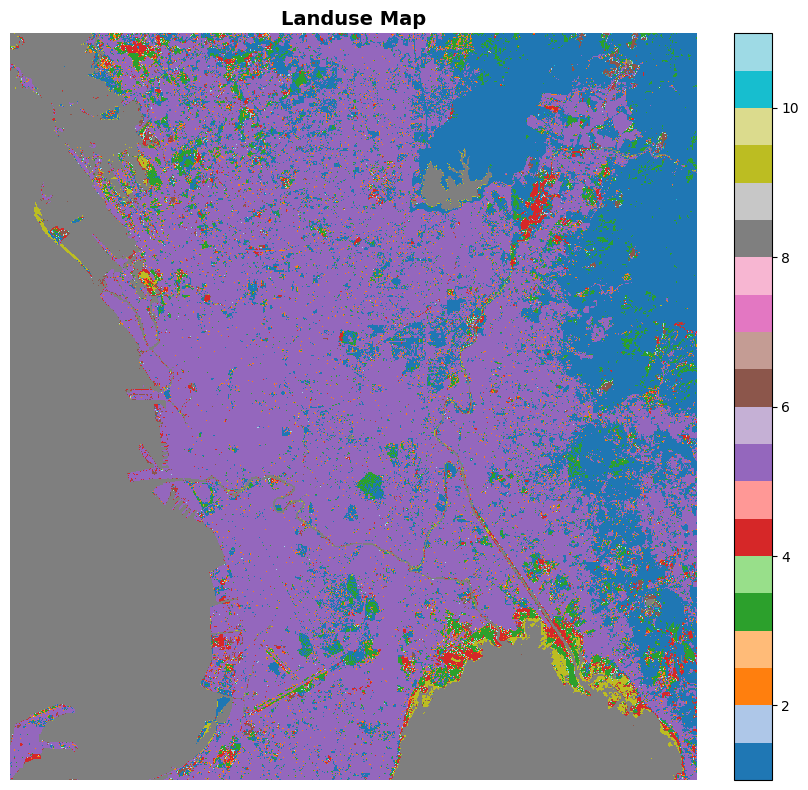

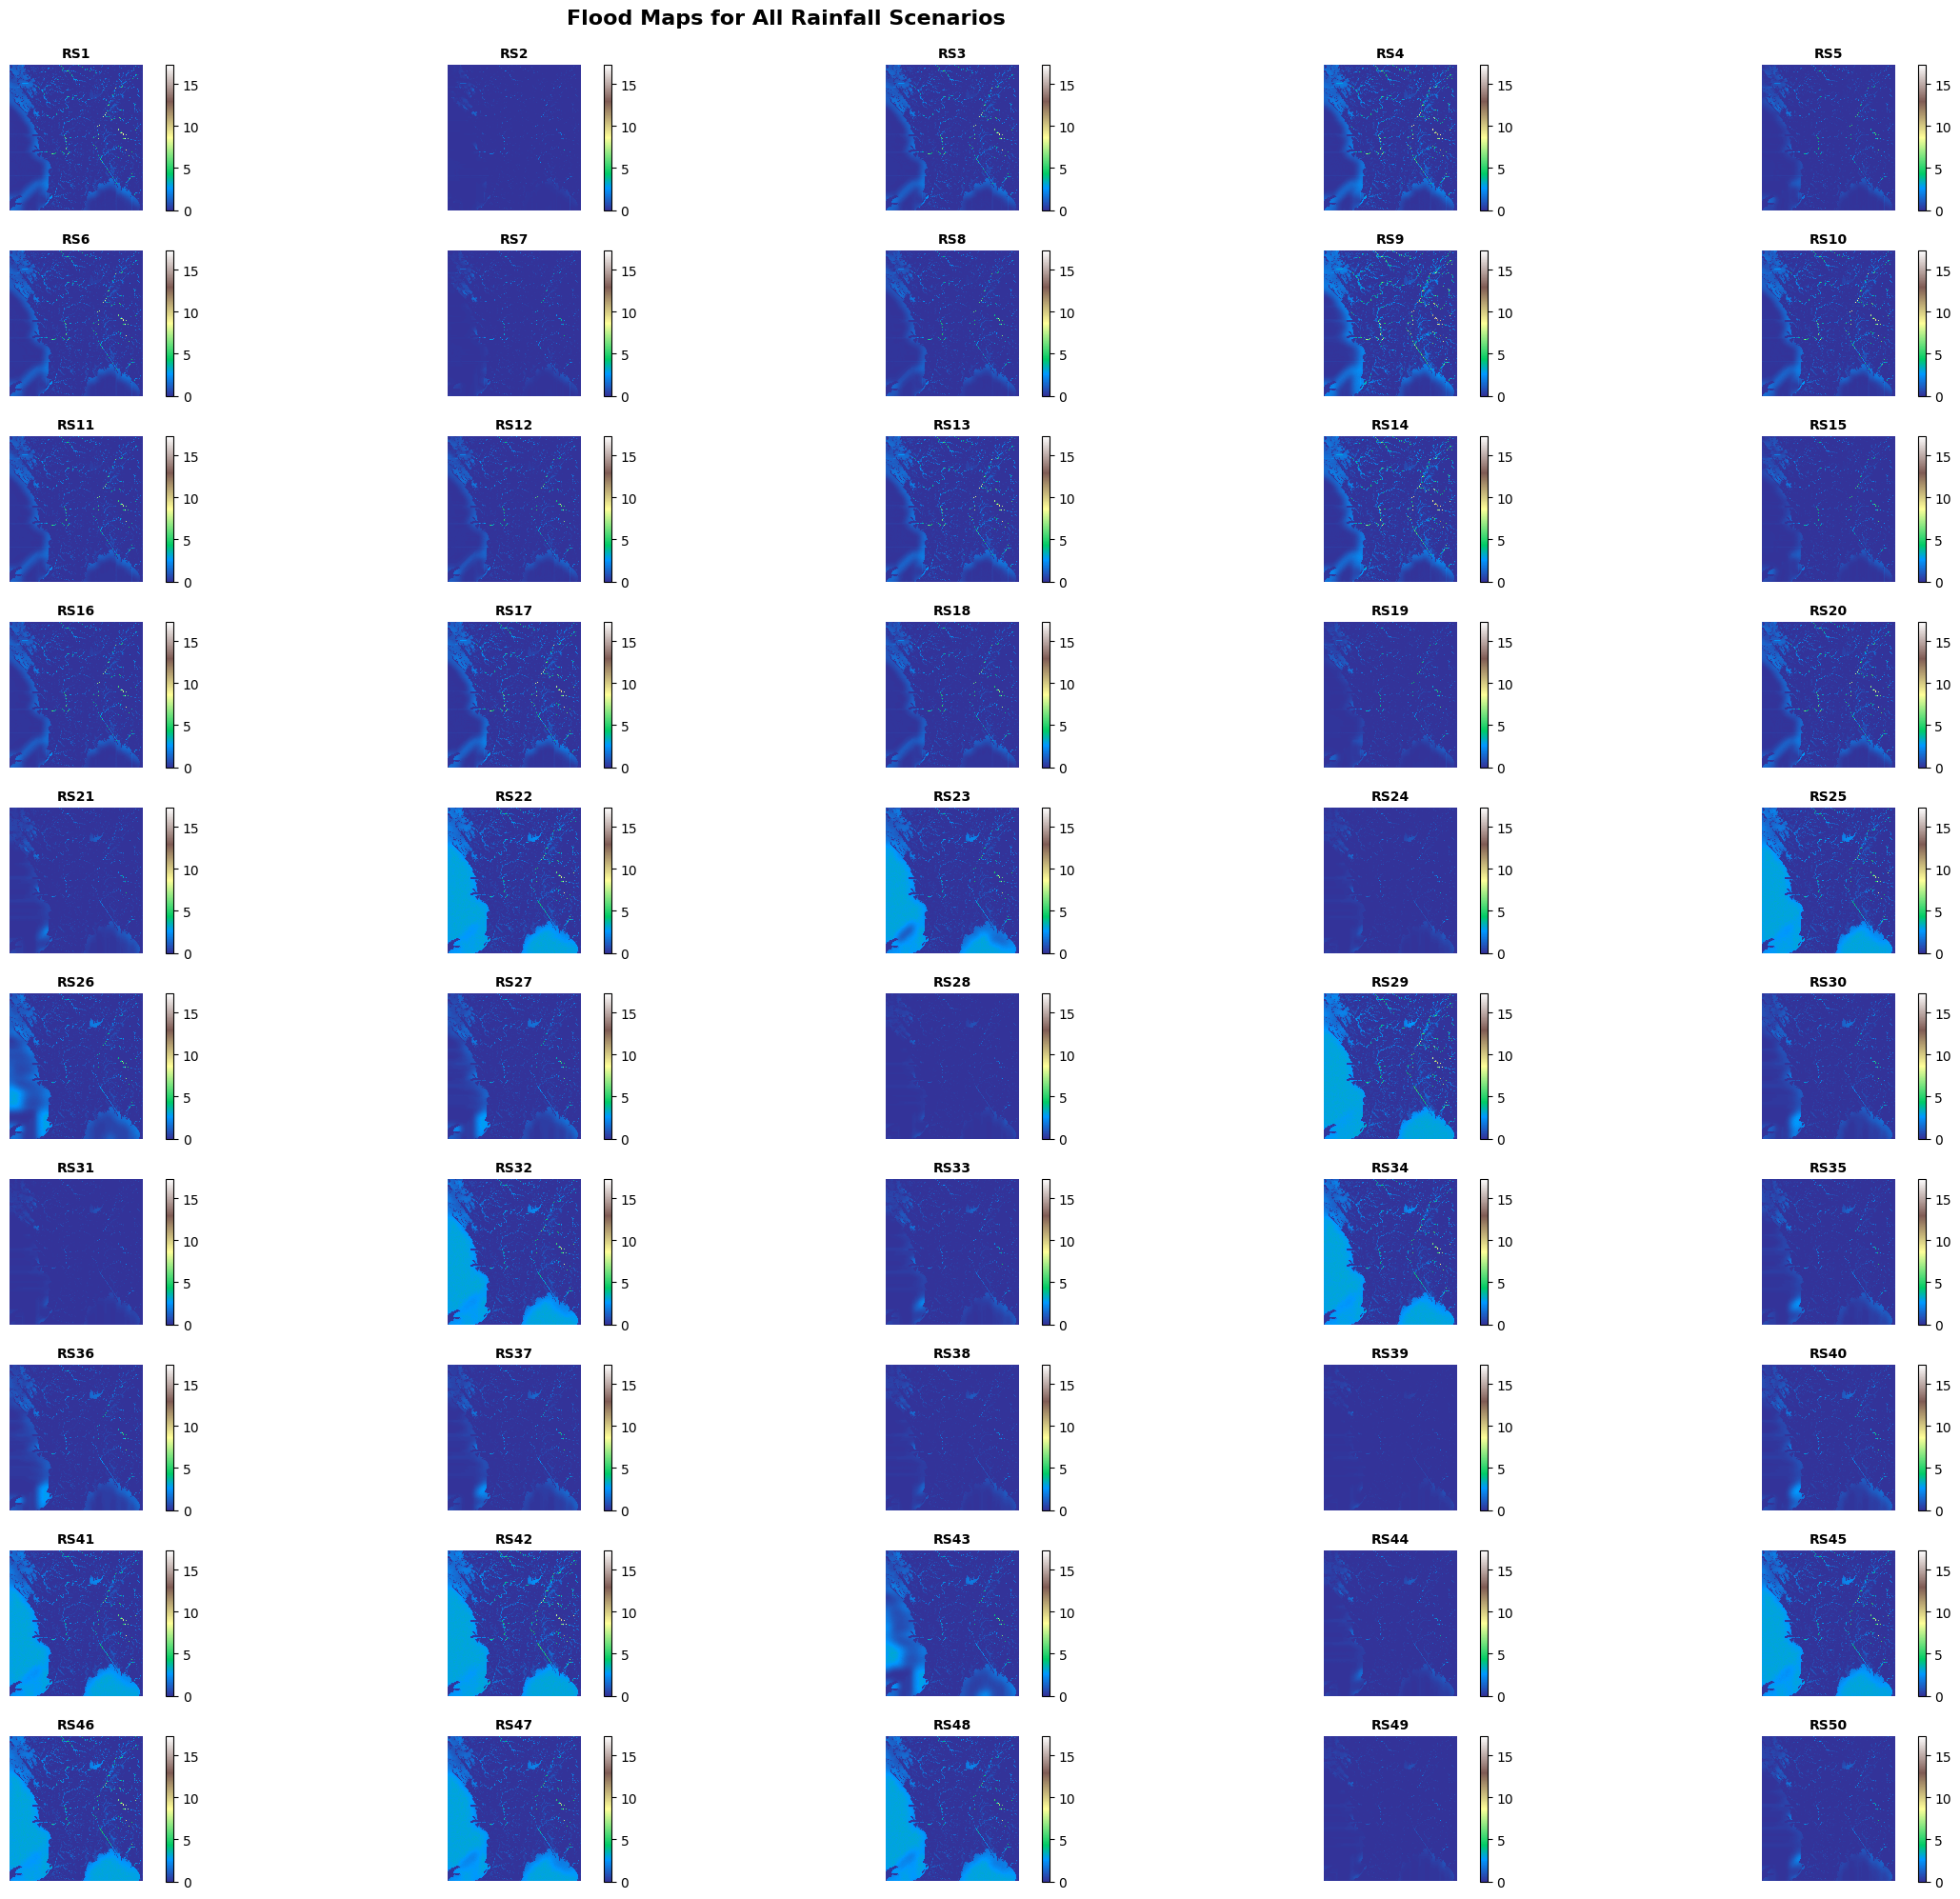

In [3]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_path, "greater_mm_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data = None

fig1 = visualize_raster(dem_data, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_path, "GM_Infilt_fixed.tif")
if os.path.exists(infilt_path):
    infilt_data, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(infilt_data, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(gmm_path, "GM_LU.tif")
if os.path.exists(landuse_path):
    landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None
    
fig3 = visualize_raster(landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_path, "exp-des-4")
flood_maps, flood_metadata = gmm_path_load_all_flood_maps(gmm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

In [4]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rainfall_path)

LOADING RAINFALL SCENARIOS
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 3 loaded: 13 time steps
Rainfall Scenario 4 loaded: 13 time steps
Rainfall Scenario 5 loaded: 13 time steps
Rainfall Scenario 6 loaded: 13 time steps
Rainfall Scenario 7 loaded: 13 time steps
Rainfall Scenario 8 loaded: 13 time steps
Rainfall Scenario 9 loaded: 13 time steps
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps
Rainfall Scenario 21 loaded: 13 time steps
Rainfall Scenario 22 loaded: 13 time steps
Rainfall Scenario 23 loaded: 13 time

# Data Preprocessing

In [5]:
print("\nProcessing DEM...")
dem_clean = handle_nodata(dem_data, nodata_value=dem_meta.get('nodata'), fill_method='mean')

print("\nProcessing Infiltration...")
infilt_clean = handle_nodata(infilt_data, nodata_value=infilt_meta.get('nodata'), fill_method='mean')

print("\nProcessing Landuse...")
landuse_clean = handle_nodata(landuse_data, nodata_value=landuse_meta.get('nodata'), fill_method='interpolate')


Processing DEM...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Infiltration...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Landuse...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found


In [6]:
# Normalize DEM
print("\nNormalizing DEM...")
dem_normalized, dem_params = normalize_dem(dem_data, method='minmax')
# Verify normalization
dem_norm_stats = get_raster_stats(dem_normalized, "DEM (Normalized)")
print_raster_stats(dem_norm_stats)

# Normalize Infiltration
print("\nNormalizing Infiltration...")
infilt_normalized, infilt_params = normalize_infiltration(infilt_data)
# Verify normalization
infilt_norm_stats = get_raster_stats(infilt_normalized, "Infiltration (Normalized)")
print_raster_stats(infilt_norm_stats)

# Normalize Landuse
print("\nNormalizing Landuse...")
landuse_normalized, landuse_params = normalize_landuse(landuse_data, method='minmax')
# Verify normalization
landuse_norm_stats = get_raster_stats(landuse_normalized, "Landuse (Normalized)")
print_raster_stats(landuse_norm_stats)



Normalizing DEM...
DEM normalized (min-max): [-9.1316, 466.3908] -> [0.0, 1.0]

Statistics for: DEM (Normalized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1077
Std dev:       0.1452
Valid pixels:  1,377,000 / 1,377,000


Normalizing Infiltration...
Infiltration normalized (min-max): [0.0000, 3.6847] -> [0.0, 1.0]

Statistics for: Infiltration (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1308
Std dev:       0.2574
Valid pixels:  1,377,000 / 1,377,000


Normalizing Landuse...
Landuse normalized (min-max): [1.0000, 11.0000] -> [0.0, 1.0]

Statistics for: Landuse (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.3934
Std dev:       0.2501
Valid pixels:  1,377,000 / 1,377,000



# Flood Maps (Ground Truths)

In [7]:
flood_maps_categorized_patch, patch_metadata = categorize_all_flood_maps_patch(
    flood_maps, 
    patch_size=PATCH_SIZE, 
    FLOOD_CLASSES=FLOOD_CLASSES_VEC,
    verbose=True
)


PATCH-BASED FLOOD MAP CATEGORIZATION

Configuration:
  Patch size: 4×4
  Stride: 4 (non-overlapping)
  Categorization method: majority

Class definitions:
  Class 0: No Flood     [0.00, 0.15) m
  Class 1: Light        [0.15, 0.24) m
  Class 2: Moderate     [0.24, 0.46) m
  Class 3: Heavy        [0.46, 0.68) m
  Class 4: Extreme      [0.68, ∞) m

Scenario  1 (85986 patches):
  No Flood    : 64,152 patches (74.61%)
  Light       :  1,892 patches ( 2.20%)
  Moderate    :  3,905 patches ( 4.54%)
  Heavy       :  2,618 patches ( 3.04%)
  Extreme     : 13,419 patches (15.61%)
Scenario  2 (85986 patches):
  No Flood    : 82,402 patches (95.83%)
  Light       :  1,322 patches ( 1.54%)
  Moderate    :  1,553 patches ( 1.81%)
  Heavy       :    364 patches ( 0.42%)
  Extreme     :    345 patches ( 0.40%)
Scenario  3 (85986 patches):
  No Flood    : 64,911 patches (75.49%)
  Light       :  1,993 patches ( 2.32%)
  Moderate    :  3,906 patches ( 4.54%)
  Heavy       :  2,737 patches ( 3.18%)
  Ex

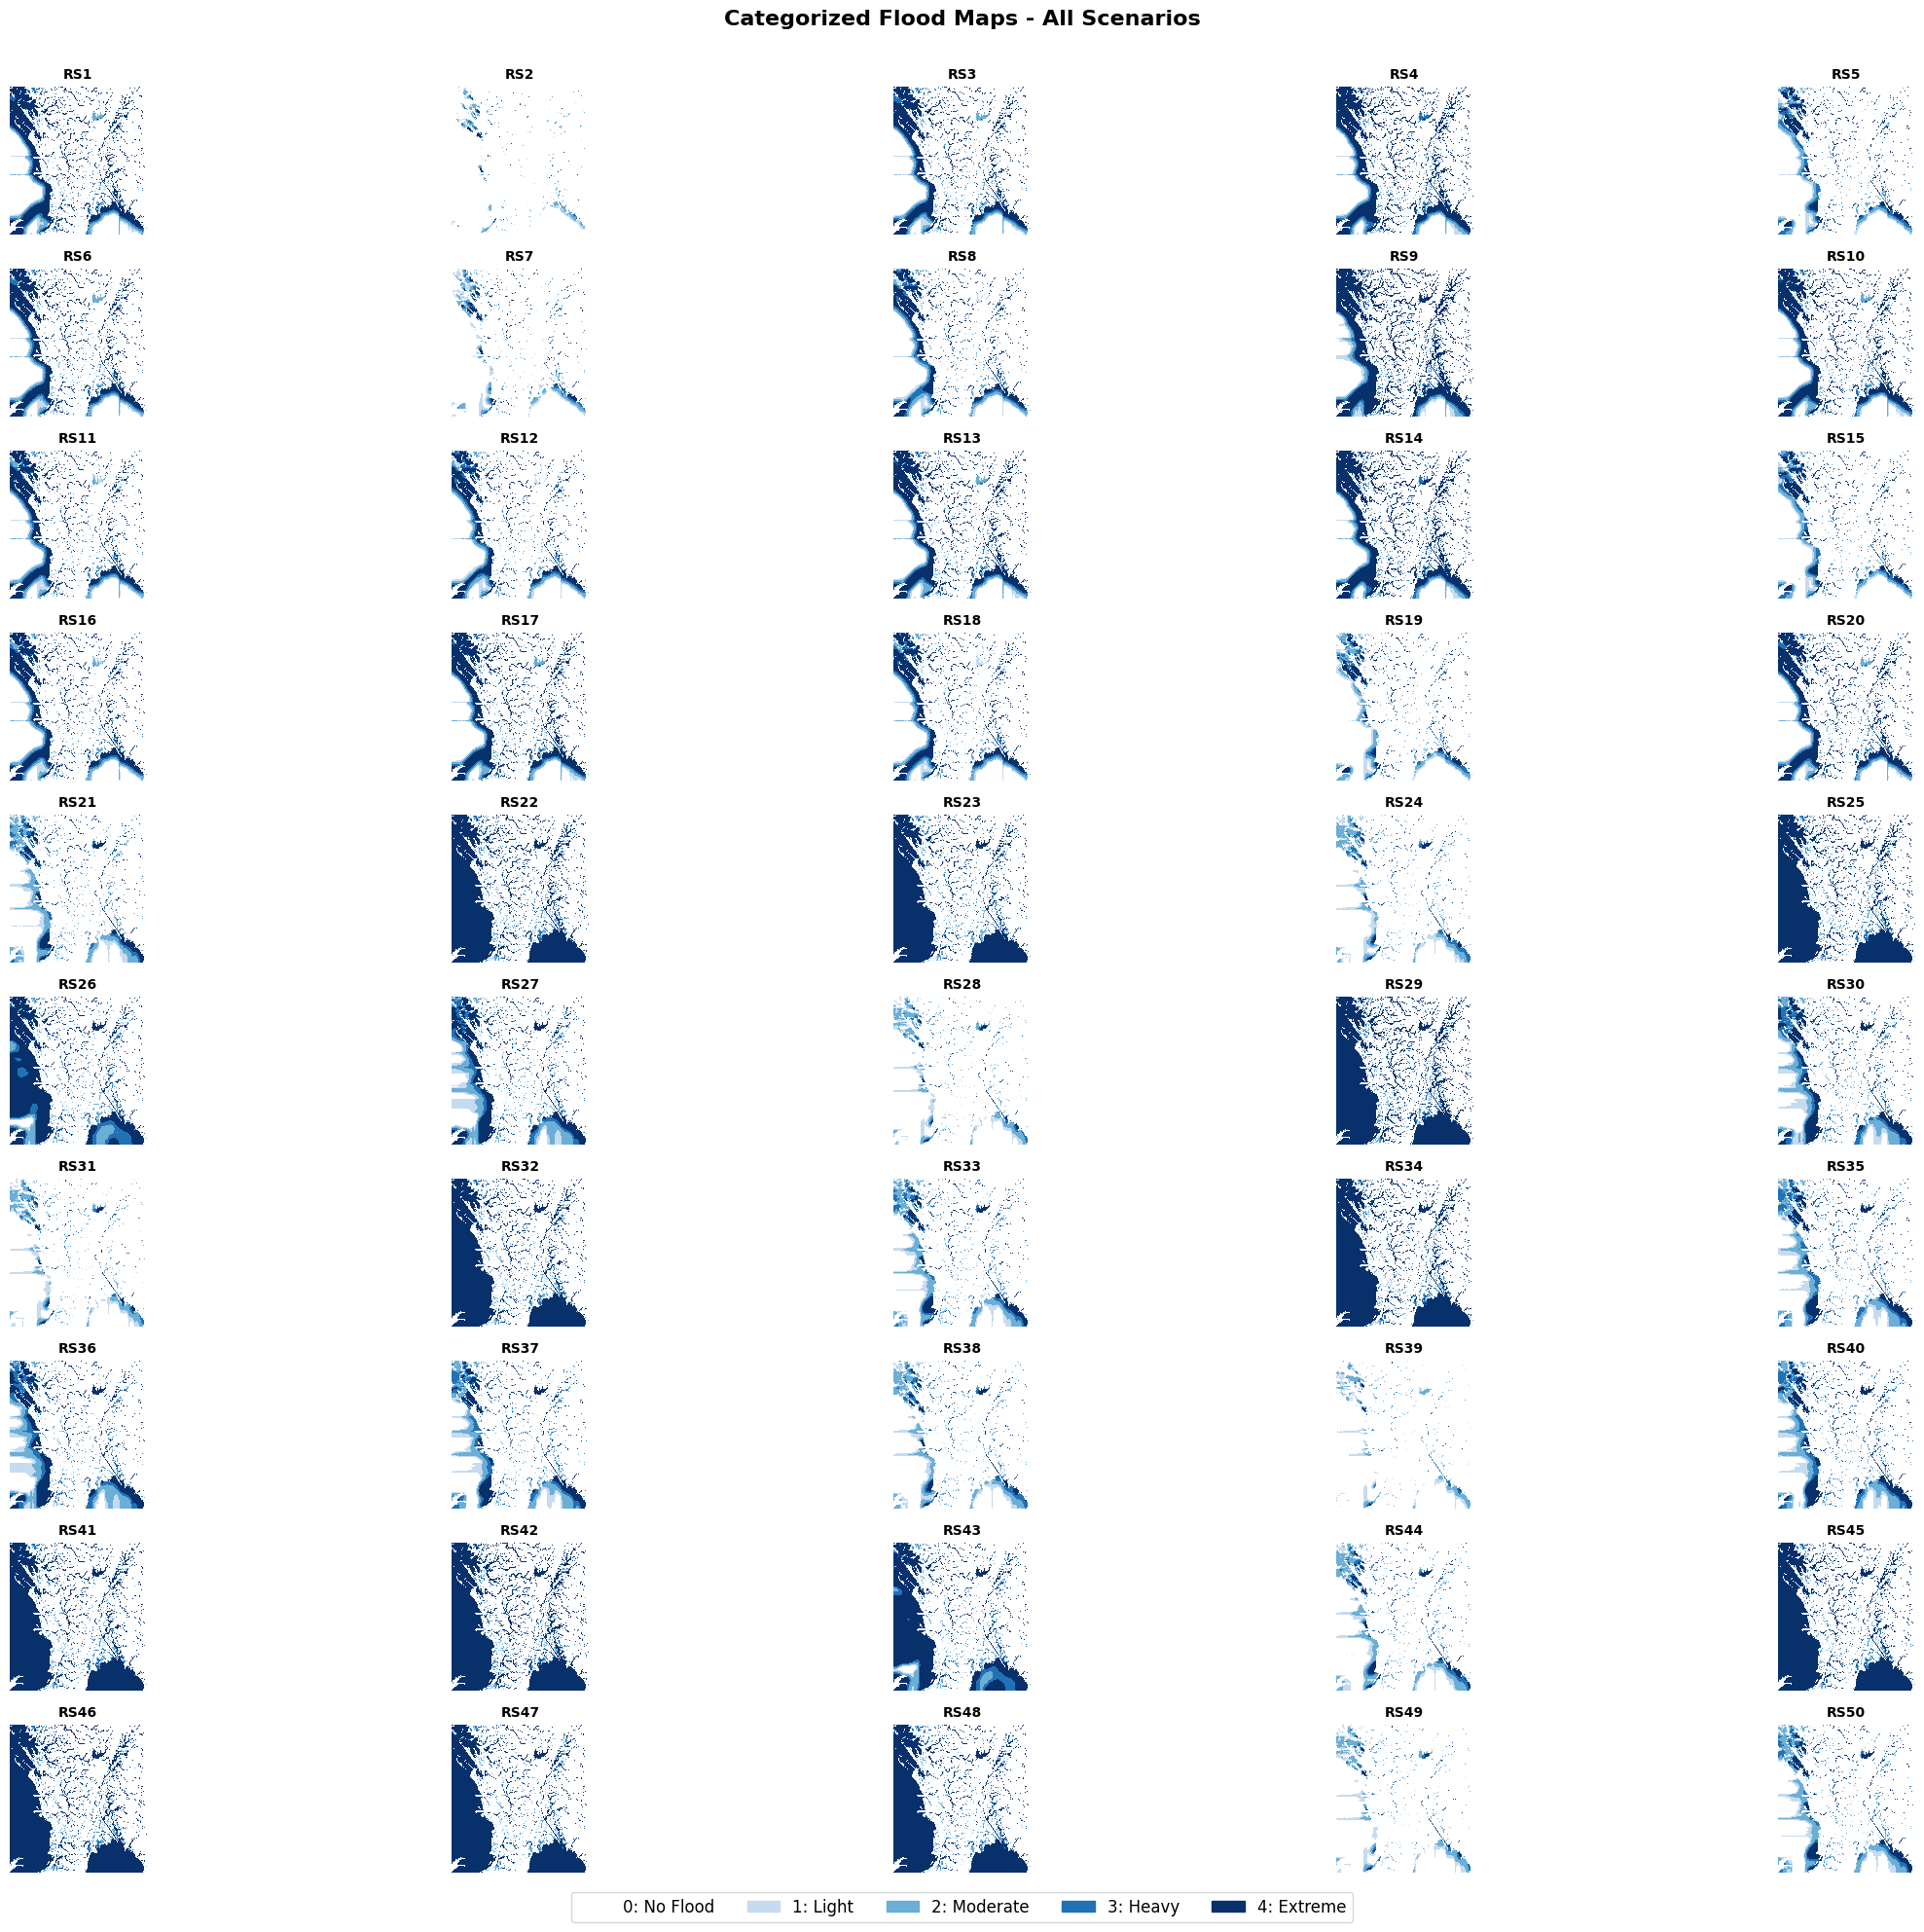

In [8]:
reconstructed_maps = []
for patch_labels, metadata in zip(flood_maps_categorized_patch, patch_metadata):
    reconstructed = reconstruct_map_from_patches(patch_labels, metadata, method='nearest')
    reconstructed_maps.append(reconstructed)

fig_all = visualize_all_categorized_maps(
    reconstructed_maps, 
    FLOOD_CLASSES=FLOOD_CLASSES_VEC,
    scenario_ids=list(range(1, 51))
)

plt.show()

In [9]:
display(flood_maps_categorized_patch)

[array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([1, 1, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4,

# Rainfall

In [10]:
import numpy as np
import pandas as pd
from typing import Dict, Any, List

# ── Storm Type Registry ───────────────────────────────────────────────────────
NUM_STORM_TYPES = 4
STORM_TYPE_MAP = {
    1: "SCS Front-loaded",
    2: "SCS Balanced",
    3: "SCS Back-loaded",
    4: "Triangular",
}

def _infer_type_id_from_sid(sid: int) -> int:
    if   1  <= sid <= 10: return 1
    elif 11 <= sid <= 20: return 2
    elif 21 <= sid <= 30: return 3
    elif 31 <= sid <= 50: return 4
    else:
        raise ValueError(f"Scenario ID {sid} out of expected range 1–50")

# ── Loader ────────────────────────────────────────────────────────────────────
def load_scenario_metadata(info_csv_path: str) -> Dict[int, Dict[str, Any]]:
    df = pd.read_csv(info_csv_path)

    required = {
        "No",
        "Pattern Type",
        "Total storm depth P (mm)",
        "Peak time fraction r (tpeak / D)",
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"info.csv missing columns: {missing}")

    metadata = {}

    for _, row in df.iterrows():
        sid = int(row["No"])
        type_id = _infer_type_id_from_sid(sid)

        # r = 0.0 for SCS types; actual value for triangular
        if type_id in (1, 2, 3):
            r = 0.0
        else:
            r = float(row["Peak time fraction r (tpeak / D)"])

        metadata[sid] = {
            "type_id": type_id,
            "label": STORM_TYPE_MAP[type_id],
            "pattern_type": row["Pattern Type"],
            "total_depth_mm": float(row["Total storm depth P (mm)"]),
            "r": r,
        }

    print(f"Loaded {len(metadata)} scenarios from {info_csv_path}")
    return metadata

# ── One-Hot Encoding ──────────────────────────────────────────────────────────
def get_storm_type_onehot(sid: int, scenario_metadata: Dict[int, Dict[str, Any]]) -> np.ndarray:
    """Return (4,) one-hot vector for storm type."""
    type_id = scenario_metadata[sid]["type_id"]
    onehot = np.zeros(NUM_STORM_TYPES, dtype=np.float32)
    onehot[type_id - 1] = 1.0
    return onehot

def build_all_storm_onehots(scenario_metadata: Dict[int, Dict[str, Any]]) -> np.ndarray:
    """Return (N_scenarios, 4) one-hot matrix."""
    sids = sorted(scenario_metadata.keys())
    onehots = np.stack(
        [get_storm_type_onehot(sid, scenario_metadata) for sid in sids],
        axis=0
    )

    print(f"Storm one-hot matrix shape: {onehots.shape}")
    return onehots

# ── Conditioning Vector ───────────────────────────────────────────────────────
# rain(13) + onehot(4) + r(1) + depth_norm(1) = 19 dims
CONDITIONING_DIM = 19

def build_conditioning_vector(
    rain_normalized: np.ndarray,  # (13,)
    type_id: int,                 # 1
    r: float,                     # 0.0
    total_depth_mm: float,        # 38.0
    depth_min: float,             # 5.0
    depth_max: float,             # 78.0
) -> np.ndarray:
    """Build full (19,) conditioning vector."""

    # Step 1: Create one-hot for storm type
    onehot = np.zeros(4, dtype=np.float32)
    onehot[type_id - 1] = 1.0  # type_id=1 → onehot[0]=1.0
    # Result: [1.0, 0.0, 0.0, 0.0]

    # Step 2: Normalize depth to [0, 1]
    depth_norm = (total_depth_mm - depth_min) / (depth_max - depth_min)

    # Step 3: Concatenate all 19 dimensions
    return np.concatenate([
        rain_normalized.astype(np.float32),   # (13,) rainfall
        onehot,                               # (4,) storm type one-hot
        [np.float32(r)],                      # (1,) r parameter → [0.0]
        [np.float32(depth_norm)],             # (1,) normalized depth → [0.452]
    ])
    # Result: (19,) vector


def build_all_conditioning_vectors(
    rain_embeddings: np.ndarray,  # (50, 13) — normalized rainfall sequences
    scenario_metadata: Dict[int, Dict[str, Any]],  # 50 scenarios' metadata
    depth_min: float,             # Min depth from training (5.0 mm)
    depth_max: float,             # Max depth from training (78.0 mm)
) -> np.ndarray:                  # Returns (50, 19) — full conditioning vectors
    """Build (N_scenarios, 19) conditioning matrix."""

    sids = sorted(scenario_metadata.keys())  # [1, 2, 3, ..., 50]
    vectors = []

    for i, sid in enumerate(sids):
        m = scenario_metadata[sid]  # Get metadata for this scenario

        vec = build_conditioning_vector(
            rain_normalized=rain_embeddings[i],      # (13,) rainfall for scenario i
            type_id=m["type_id"],                    # 1, 2, 3, or 4 (storm type)
            r=m["r"],                                # 0.0 for SCS, tpeak for triangular
            total_depth_mm=m["total_depth_mm"],      # Actual depth (mm)
            depth_min=depth_min,                     # 5.0
            depth_max=depth_max,                     # 78.0
        )

        vectors.append(vec)

    out = np.stack(vectors, axis=0)  # Stack all 50 vectors → (50, 19)

    print(f"Conditioning matrix shape: {out.shape}")
    return out


# ── Validation ────────────────────────────────────────────────────────────────
def validate_and_print_metadata(
    scenario_metadata: Dict[int, Dict[str, Any]],
    train_ids: List[int],
    test_ids: List[int],
) -> None:

    print("\n" + "=" * 70)
    print("SCENARIO METADATA SUMMARY")
    print("=" * 70)

    all_ids = sorted(scenario_metadata.keys())
    print(f"\nTotal scenarios: {len(all_ids)}")

    # Full dataset distribution
    print("\nStorm type distribution (full dataset):")

    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid, m in scenario_metadata.items()
               if m["type_id"] == tid]

        if not ids:
            continue

        depths = [scenario_metadata[sid]["total_depth_mm"] for sid in ids]

        print(f"  Type {tid} - {label:<18}: "
              f"{len(ids):>2} scenarios  "
              f"(IDs {min(ids)}–{max(ids)})  "
              f"depth {min(depths):.0f}–{max(depths):.0f} mm")

    # Train distribution
    print("\nTrain set distribution:")
    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid in train_ids
               if scenario_metadata[sid]["type_id"] == tid]
        print(f"  Type {tid} - {label:<18}: {len(ids)}")

    # Test distribution
    print("\nTest set distribution:")
    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid in test_ids
               if scenario_metadata[sid]["type_id"] == tid]
        print(f"  Type {tid} - {label:<18}: {len(ids)}")

    # Triangular r range
    triangular = [
        m["r"] for m in scenario_metadata.values()
        if m["type_id"] == 4
    ]

    if triangular:
        print(f"\nTriangular r range: "
              f"{min(triangular):.2f} – {max(triangular):.2f}")

    print("=" * 70)

In [11]:
scenario_metadata = load_scenario_metadata(os.path.join(repo_root, "info.csv"))
validate_and_print_metadata(scenario_metadata, 
                             list(range(1, NUM_SCENARIO+1)),
                             list(range(1, NUM_SCENARIO+1)))

# ── Depth normalization stats (from training data) ────────────────────────────
all_depths = [m['total_depth_mm'] for m in scenario_metadata.values()]
depth_min, depth_max = min(all_depths), max(all_depths)
print(f"Depth range: {depth_min:.1f} – {depth_max:.1f} mm")


Loaded 50 scenarios from c:\Users\CENSER\th3-experiments\info.csv

SCENARIO METADATA SUMMARY

Total scenarios: 50

Storm type distribution (full dataset):
  Type 1 - SCS Front-loaded  : 10 scenarios  (IDs 1–10)  depth 6–78 mm
  Type 2 - SCS Balanced      : 10 scenarios  (IDs 11–20)  depth 19–78 mm
  Type 3 - SCS Back-loaded   : 10 scenarios  (IDs 21–30)  depth 7–75 mm
  Type 4 - Triangular        : 20 scenarios  (IDs 31–50)  depth 5–77 mm

Train set distribution:
  Type 1 - SCS Front-loaded  : 10
  Type 2 - SCS Balanced      : 10
  Type 3 - SCS Back-loaded   : 10
  Type 4 - Triangular        : 20

Test set distribution:
  Type 1 - SCS Front-loaded  : 10
  Type 2 - SCS Balanced      : 10
  Type 3 - SCS Back-loaded   : 10
  Type 4 - Triangular        : 20

Triangular r range: 0.10 – 0.90
Depth range: 5.0 – 78.0 mm


In [12]:
print(scenario_metadata)

{1: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 38.0, 'r': 0.0}, 2: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 6.0, 'r': 0.0}, 3: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 34.0, 'r': 0.0}, 4: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 54.0, 'r': 0.0}, 5: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 17.0, 'r': 0.0}, 6: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 33.0, 'r': 0.0}, 7: {'type_id': 1, 'lab

# Data Splitting Strategy

In [13]:
print("Stack Spatial Inputs")
spatial_stack = stack_spatial_inputs(dem_normalized, infilt_normalized, landuse_normalized)

print("Flood maps already categorized →", len(flood_maps_categorized_patch), "scenarios")

print("Quadrant Split — Spatial Stack")
spatial_quadrants = split_into_quadrants(spatial_stack)

print("\nExtract Spatial Patches (full map)")
spatial_patches = extract_spatial_patches(spatial_stack, patch_size=PATCH_SIZE)

print("\nCompute Quadrant Patch Indices")
H, W = dem_normalized.shape
quadrant_indices = get_quadrant_patch_indices(H, W, patch_size=PATCH_SIZE)

print("\nBuild Train / Test Split")
dataset = build_train_test_split(spatial_patches, flood_maps_categorized_patch, quadrant_indices, rainfall_scenarios=rainfall_scenarios,)

Stack Spatial Inputs
[Stack] Spatial input shape: (1224, 1125, 3)  |  Channels: DEM, Infiltration, Landuse
Flood maps already categorized → 50 scenarios
Quadrant Split — Spatial Stack
  [Q1 | TRAIN] shape: (612, 562, 3)
  [Q2 | TRAIN] shape: (612, 562, 3)
  [Q3 | TEST] shape: (612, 562, 3)
  [Q4 | TRAIN] shape: (612, 562, 3)

Extract Spatial Patches (full map)
  Spatial patches extracted: 85,986  shape: (85986, 4, 4, 3)

Compute Quadrant Patch Indices
  [Q1 | TRAIN] 21,420 patches
  [Q2 | TRAIN] 21,573 patches
  [Q3 | TEST] 21,420 patches
  [Q4 | TRAIN] 21,573 patches

Build Train / Test Split

QUADRANT SPLIT SUMMARY
  Train quadrants  : ['Q1', 'Q2', 'Q4']
  Test  quadrants  : ['Q3']
  X_train          : (64566, 4, 4, 3)  (patches, h, w, C)
  X_test           : (21420, 4, 4, 3)   (patches, h, w, C)
  y_train          : (50, 64566)  (scenarios, patches)  — int8 class
  y_test           : (50, 21420)   (scenarios, patches)  — int8 class
  Rainfall         : 50 scenarios (NOT split spatia

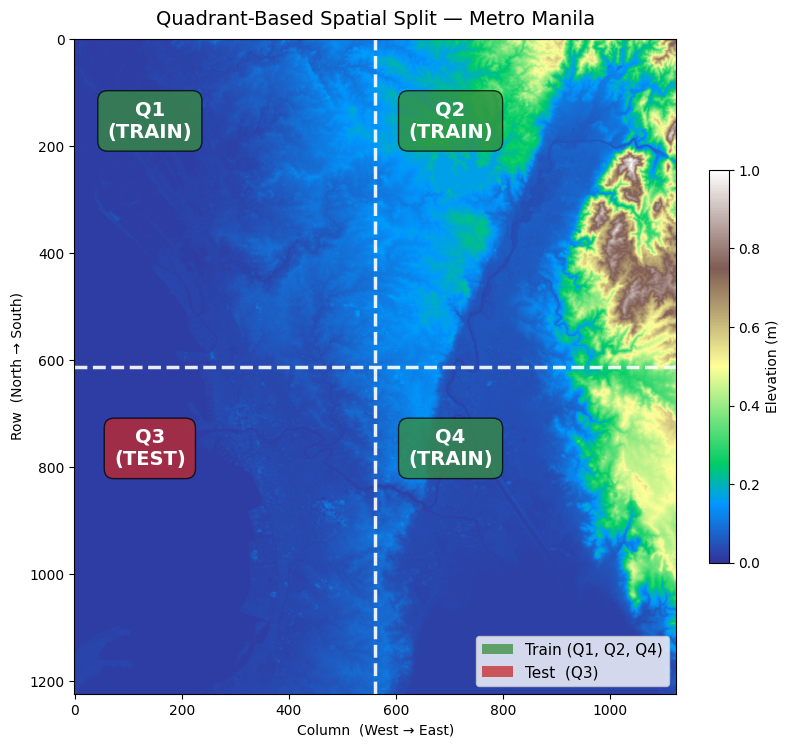

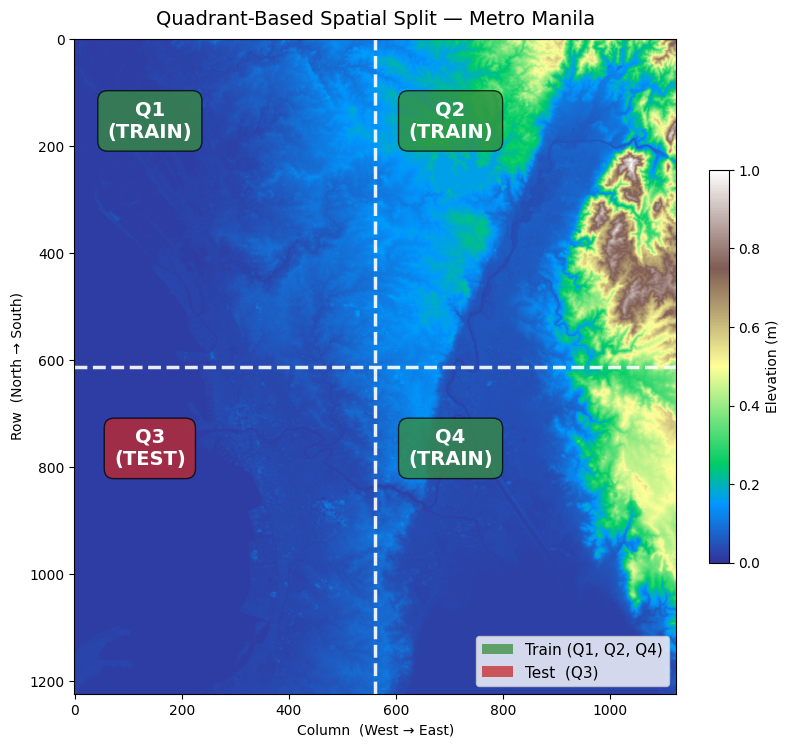

In [14]:
visualize_quadrant_split(dem_normalized)

# Rainfall Encoding

In [15]:
all_intensities = np.concatenate([df['intensity_mmhr'].values for df in rainfall_scenarios])
rain_min, rain_max = all_intensities.min(), all_intensities.max()

def normalize_rainfall_scenarios(rainfall_scenarios, rain_min, rain_max):
    normalized = []
    for df in rainfall_scenarios:
        intensity = (df['intensity_mmhr'].values - rain_min) / (rain_max - rain_min)
        normalized.append(intensity.astype(np.float32))
    return np.stack(normalized, axis=0) 

rain_embeddings = normalize_rainfall_scenarios(rainfall_scenarios, rain_min, rain_max)
print(rain_embeddings.shape) 

(50, 13)


# Manila Mask


--- Loading Manila Mask ---
Manila mask loaded: shape (389, 358), dtype float32

Statistics for: Mask
Shape:         (389, 358)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0747
Std dev:       0.2629
Valid pixels:  139,262 / 139,262



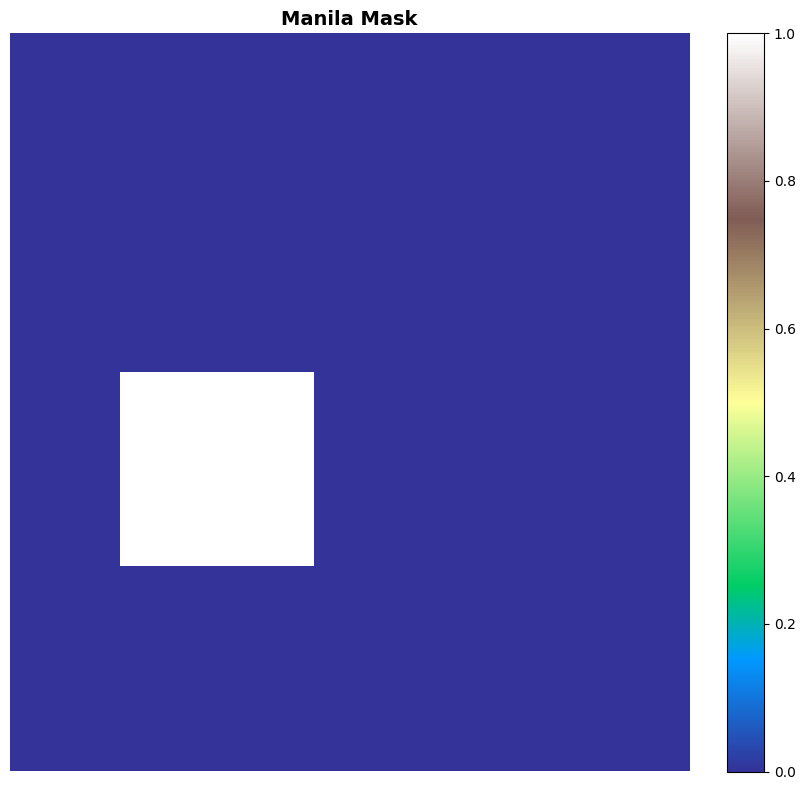

In [16]:
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
if os.path.exists(mask_path):
    mask_data, mask_meta = load_manila_mask(mask_path)
    mask_stats = get_raster_stats(mask_data, "Mask")
    print_raster_stats(mask_stats)
else:
    print(f"WARNING: Mask file not found at {mask_path}")

fig1 = visualize_raster(mask_data, title="Manila Mask", cmap='terrain')

In [17]:
from scipy.ndimage import zoom

# ── Upsample Manila mask to match spatial stack resolution ───────────────────
print("Aligning Manila mask to spatial stack...")

H_stack, W_stack = dem_normalized.shape   # 1224, 1125
H_mask,  W_mask  = mask_data.shape        # 389, 358

zoom_h = H_stack / H_mask   # ~3.147
zoom_w = W_stack / W_mask   # ~3.144

# Nearest-neighbor zoom (preserve binary 0/1)
mask_upsampled = zoom(mask_data, (zoom_h, zoom_w), order=0)  # (1224, 1125)
mask_upsampled = (mask_upsampled >= 0.5).astype(bool)

print(f"  mask original  : {mask_data.shape}")
print(f"  mask upsampled : {mask_upsampled.shape}  (matches spatial stack)")
print(f"  Manila pixels  : {mask_upsampled.sum():,} of {mask_upsampled.size:,} ({mask_upsampled.mean()*100:.1f}%)")

# ── Build patch-level mask via majority vote ──────────────────────────────────
print("\nBuilding patch-level mask...")

N_H, N_W = 306, 281   # full patch grid dimensions
patch_mask = np.zeros((N_H, N_W), dtype=bool)

for i in range(N_H):
    for j in range(N_W):
        r0, r1 = i*PATCH_SIZE, (i+1)*PATCH_SIZE
        c0, c1 = j*PATCH_SIZE, (j+1)*PATCH_SIZE
        patch = mask_upsampled[r0:r1, c0:c1]
        patch_mask[i, j] = patch.mean() >= 0.5

manila_patch_indices = np.where(patch_mask.ravel())[0]
N_MANILA = len(manila_patch_indices)

print(f"  Patch grid      : {N_H} x {N_W} = {N_H*N_W} total patches")
print(f"  Manila patches  : {N_MANILA} ({N_MANILA/(N_H*N_W)*100:.1f}%)")

# ── Filter spatial_patches to Manila only ────────────────────────────────────
manila_patches = spatial_patches[manila_patch_indices]   # (N_MANILA, 4, 4, 3)
print(f"  manila_patches  : {manila_patches.shape}")

# ── Save ─────────────────────────────────────────────────────────────────────
save_path = 'checkpoints_ped/spatial_data.npz'
np.savez(
    save_path,
    spatial              = manila_patches.astype(np.float32),
    manila_patch_indices = manila_patch_indices,   # (N_MANILA,) to reconstruct 2D map
    rain_min             = np.array([rain_min]),
    rain_max             = np.array([rain_max]),
    n_h                  = np.array([N_H]),        # 306 — full grid rows
    n_w                  = np.array([N_W]),        # 281 — full grid cols
)

print(f"\n  Saved -> {save_path}")
print(f"    spatial              : {manila_patches.shape}")
print(f"    manila_patch_indices : {manila_patch_indices.shape}")
print(f"    n_h, n_w             : {N_H}, {N_W}  (full grid, not Manila-only)")
print(f"    rain_min / rain_max  : {rain_min:.4f} / {rain_max:.4f}")

Aligning Manila mask to spatial stack...
  mask original  : (389, 358)
  mask upsampled : (1224, 1125)  (matches spatial stack)
  Manila pixels  : 103,362 of 1,377,000 (7.5%)

Building patch-level mask...
  Patch grid      : 306 x 281 = 85986 total patches
  Manila patches  : 6480 (7.5%)
  manila_patches  : (6480, 4, 4, 3)

  Saved -> checkpoints_ped/spatial_data.npz
    spatial              : (6480, 4, 4, 3)
    manila_patch_indices : (6480,)
    n_h, n_w             : 306, 281  (full grid, not Manila-only)
    rain_min / rain_max  : 0.0000 / 189.8531


In [18]:
# ── Build conditioning vectors (19-dim) ───────────────────────────────────────
# rain_embeddings shape: (50, 13) — already built
conditioning_vectors = build_all_conditioning_vectors(
    rain_embeddings   = rain_embeddings,      # (50, 13)
    scenario_metadata = scenario_metadata,
    depth_min         = depth_min,
    depth_max         = depth_max,
)   # → (50, 19)


Conditioning matrix shape: (50, 19)


In [19]:
print("\nConditioning vector breakdown (dims):")
print("  [0 :13] = normalized rainfall sequence")
print("  [13:17] = storm type one-hot")
print("  [17]    = r  (tpeak fraction)")
print("  [18]    = normalized total depth")

for sid in [1, 11, 21, 31, 40]:
    v = conditioning_vectors[sid - 1]
    print(f"\n  RS{sid:>2} ({scenario_metadata[sid]['label']:<18})"
          f"  rain[:3]={v[:3].round(3)}"
          f"  onehot={v[13:17].astype(int)}"
          f"  r={v[17]:.2f}"
          f"  depth_norm={v[18]:.3f}")


Conditioning vector breakdown (dims):
  [0 :13] = normalized rainfall sequence
  [13:17] = storm type one-hot
  [17]    = r  (tpeak fraction)
  [18]    = normalized total depth

  RS 1 (SCS Front-loaded  )  rain[:3]=[0.209 0.436 0.487]  onehot=[1 0 0 0]  r=0.00  depth_norm=0.452

  RS11 (SCS Balanced      )  rain[:3]=[0.02  0.09  0.168]  onehot=[0 1 0 0]  r=0.00  depth_norm=0.411

  RS21 (SCS Back-loaded   )  rain[:3]=[0.    0.    0.003]  onehot=[0 0 1 0]  r=0.00  depth_norm=0.123

  RS31 (Triangular        )  rain[:3]=[0.016 0.031 0.047]  onehot=[0 0 0 1]  r=0.40  depth_norm=0.041

  RS40 (Triangular        )  rain[:3]=[0.039 0.078 0.117]  onehot=[0 0 0 1]  r=0.40  depth_norm=0.205


# ViT Config

In [20]:
from config import Config
from model_config import model_factory, make_model
from training import FloodPatchDataset, train_kfold

cfg = Config()  
cfg.save(cfg.train.output_ped_dir / 'config.json')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = FloodPatchDataset(
    X_spatial = dataset['X_train'],
    y_labels  = dataset['y_train'],
    rainfall  = conditioning_vectors,
)

[FloodPatchDataset]
  Spatial tokens : torch.Size([64566, 3, 4, 4])  (N_patches, C, H, W)
  Labels         : torch.Size([64566, 50])  (N_patches, N_scenarios)
  Rainfall       : torch.Size([50, 19])  (N_scenarios, timesteps)
  Total samples  : 3,228,300  (patches × scenarios)


# Training Setup

In [21]:
# ── K-Fold Training ─────────────────────────────────────────────────────
fold_histories, best_fold = train_kfold(
    model_factory = model_factory(cfg.model),
    full_dataset  = train_dataset,
    y_train       = dataset['y_train'],
    cfg           = cfg.train,
    device        = device,
    checkpoint_dir= cfg.train.output_ped_dir
)


FOLD 1 / 2
  Train samples : 1,614,150
  Val   samples : 1,614,150
    [TRAIN] batch  1000/6306  loss=1.5325  acc=0.1329
    [TRAIN] batch  2000/6306  loss=1.5326  acc=0.1328
    [TRAIN] batch  3000/6306  loss=1.5326  acc=0.1323
    [TRAIN] batch  4000/6306  loss=1.5325  acc=0.1322
    [TRAIN] batch  5000/6306  loss=1.5325  acc=0.1321
    [TRAIN] batch  6000/6306  loss=1.5325  acc=0.1321
    [TRAIN] batch  6306/6306  loss=1.5325  acc=0.1322
    [VAL  ] batch  1000/6306  loss=1.5316  acc=0.0813
    [VAL  ] batch  2000/6306  loss=1.5318  acc=0.0816
    [VAL  ] batch  3000/6306  loss=1.5318  acc=0.0820
    [VAL  ] batch  4000/6306  loss=1.5318  acc=0.0820
    [VAL  ] batch  5000/6306  loss=1.5319  acc=0.0820
    [VAL  ] batch  6000/6306  loss=1.5319  acc=0.0820
    [VAL  ] batch  6306/6306  loss=1.5319  acc=0.0819
  Epoch  1/20  lr=0.000000  train_loss=1.5325  train_acc=0.1322  val_loss=1.5319  val_acc=0.0819  val_f1=0.0534
  → Best Macro F1: 0.0534
    [TRAIN] batch  1000/6306  loss=1.2

In [22]:
# Loading best model
import torch
from config import Config 
from model_config import make_model

cfg = Config()  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = cfg.train.output_ped_dir / f'fold_{best_fold + 1}' / 'best_model.pt'
ckpt = torch.load(model_path, map_location=device)
model = make_model(cfg.model)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device).eval()

print(f"✓ Loaded fold {best_fold+1}")
print(f"  Best macro F1: {ckpt.get('best_macro_f1', 'N/A')}")

✓ Loaded fold 1
  Best macro F1: 0.4126433039897252


In [23]:
from config import TrainConfig, ModelConfig
from dataclasses import asdict
from pathlib import Path
import json

def save_inference_config(train_config, model_config, checkpoint_dir, best_fold, output_path):
    train_dict = asdict(train_config)
    train_dict['output_dir'] = str(train_config.output_dir)
    train_dict['output_ped_dir'] = str(train_config.output_ped_dir)
    
    config = {
        'model': asdict(model_config),
        'train': train_dict,
        'best_fold': best_fold,
        'checkpoint_info': {
            'checkpoint_dir': str(checkpoint_dir)
        }
    }
    
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✓ Inference config saved to {output_path}")


save_inference_config(
    train_config=cfg.train,
    model_config=cfg.model,
    checkpoint_dir= cfg.train.output_ped_dir,
    best_fold=best_fold,
    output_path=cfg.train.output_ped_dir / 'inference_config.json'
)

✓ Inference config saved to checkpoints_ped\inference_config.json


# Testing

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from testing import ( prepare_ground_truth, evaluate_all_scenarios, plot_metrics_summary, plot_per_scenario_metrics,plot_per_class_metrics, plot_flood_on_dem )

print("\nPreparing ground truth maps for test scenarios...")
ground_truth = prepare_ground_truth(
    y_test           = dataset['y_test'],     
    quadrant_indices = quadrant_indices,
    patch_metadata   = patch_metadata[0],
)


Preparing ground truth maps for test scenarios...

Preparing ground truth maps for test scenarios...
  Q3 patch grid : 153 rows × 140 cols = 21420 patches
  GT maps shape : (50, 153, 140)  ✓


In [25]:
print("\nEvaluating all test scenarios...")
results = evaluate_all_scenarios(
    model           = model,
    X_test          = dataset['X_test'],
    y_test          = dataset['y_test'],
    conditioning_vectors = conditioning_vectors,
    ground_truth    = ground_truth,
    batch_size      = cfg.train.batch_size,
    device          = device,
    num_classes     = cfg.model.num_classes,
)


Evaluating all test scenarios...

Evaluating all test scenarios...
  RS01  Acc=0.4934  Prec=0.2604  Rec=0.2828  F1=0.2245  IoU=0.1542  Conf=0.543  Uncertain=70.0%
  RS02  Acc=0.4635  Prec=0.2046  Rec=0.2706  F1=0.1357  IoU=0.0975  Conf=0.709  Uncertain=1.0%
  RS03  Acc=0.5032  Prec=0.2596  Rec=0.2861  F1=0.2233  IoU=0.1553  Conf=0.543  Uncertain=68.4%
  RS04  Acc=0.4595  Prec=0.2684  Rec=0.2787  F1=0.2294  IoU=0.1518  Conf=0.528  Uncertain=75.0%
  RS05  Acc=0.4633  Prec=0.2407  Rec=0.2939  F1=0.1771  IoU=0.1251  Conf=0.573  Uncertain=55.6%
  RS06  Acc=0.5056  Prec=0.2615  Rec=0.2880  F1=0.2240  IoU=0.1561  Conf=0.543  Uncertain=67.9%
  RS07  Acc=0.4822  Prec=0.2427  Rec=0.2950  F1=0.1788  IoU=0.1220  Conf=0.628  Uncertain=53.3%
  RS08  Acc=0.4666  Prec=0.2642  Rec=0.3073  F1=0.1984  IoU=0.1400  Conf=0.543  Uncertain=57.8%
  RS09  Acc=0.4611  Prec=0.2855  Rec=0.2760  F1=0.2449  IoU=0.1621  Conf=0.508  Uncertain=28.8%
  RS10  Acc=0.4866  Prec=0.2634  Rec=0.2825  F1=0.2266  IoU=0.1542  C


Generating visualizations...


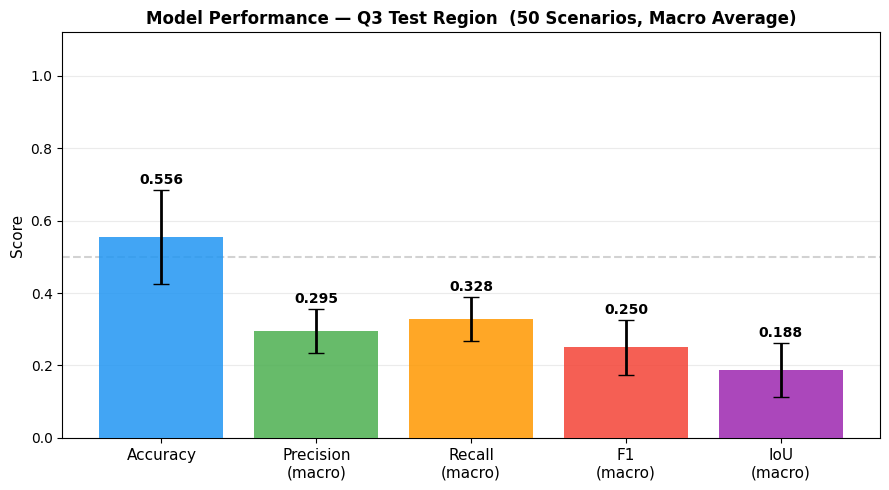

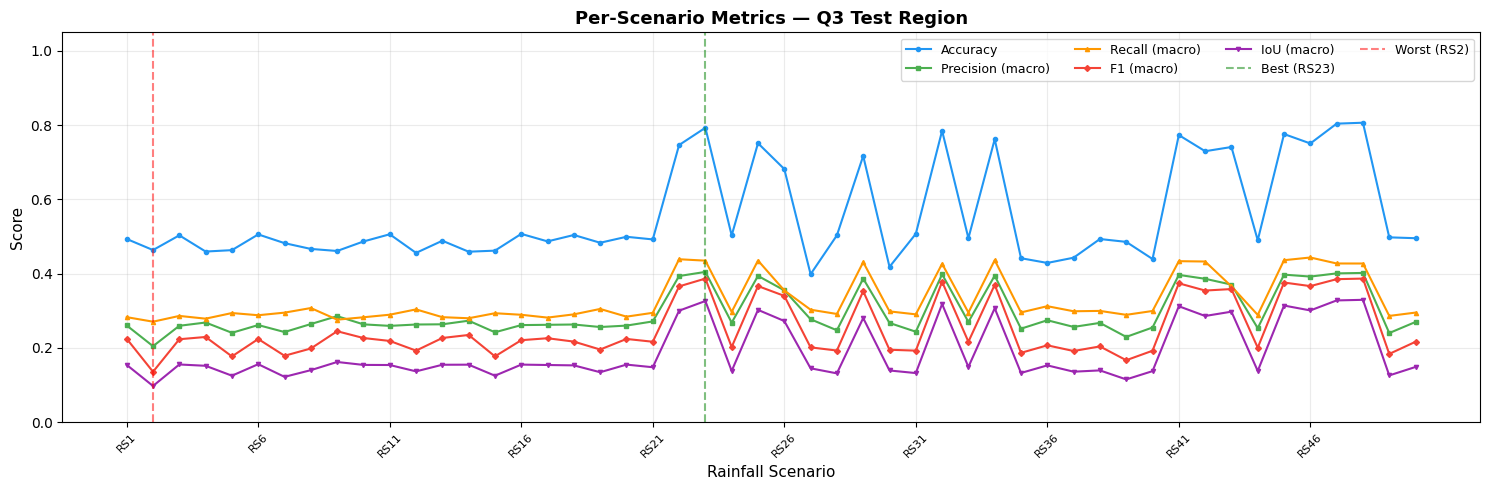

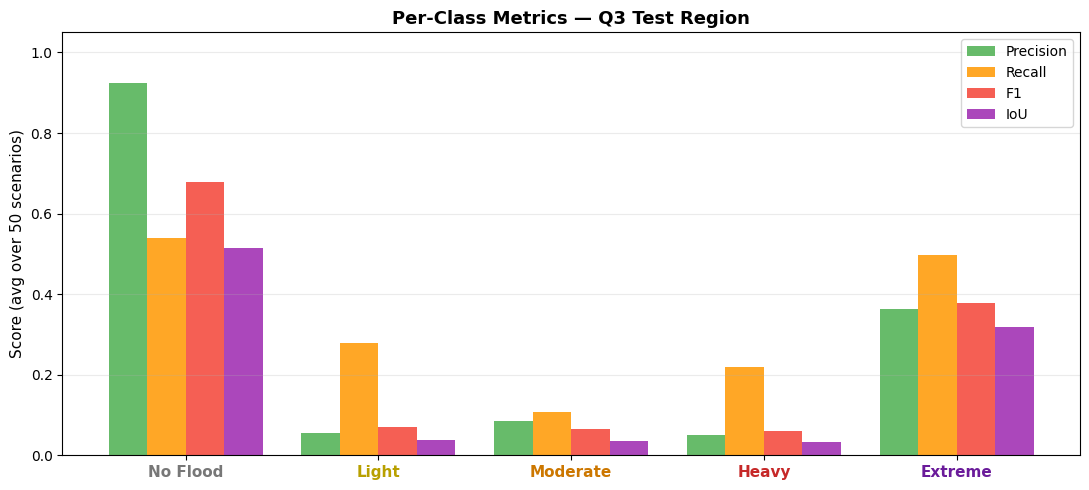

In [26]:
print("\nGenerating visualizations...")

fig1 = plot_metrics_summary(results)
fig1.savefig("eval_metrics_summary.png", dpi=150, bbox_inches='tight')

fig2 = plot_per_scenario_metrics(results)
fig2.savefig("eval_per_scenario.png", dpi=150, bbox_inches='tight')

fig3 = plot_per_class_metrics(results)
fig3.savefig("eval_per_class.png", dpi=150, bbox_inches='tight')

plt.show()

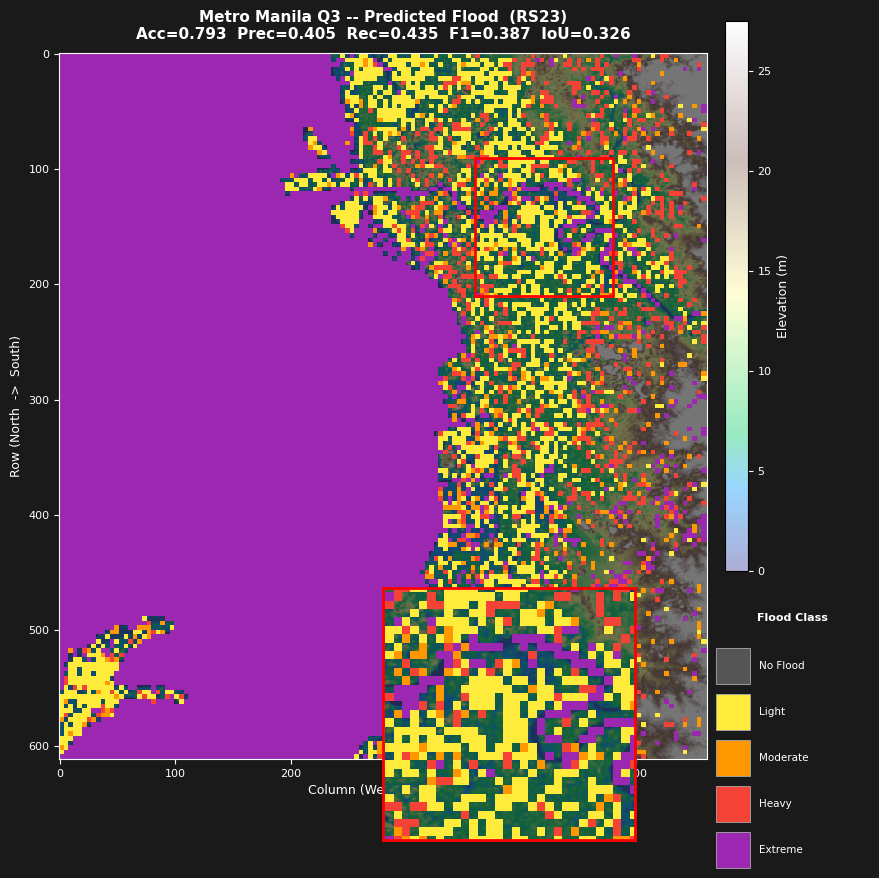

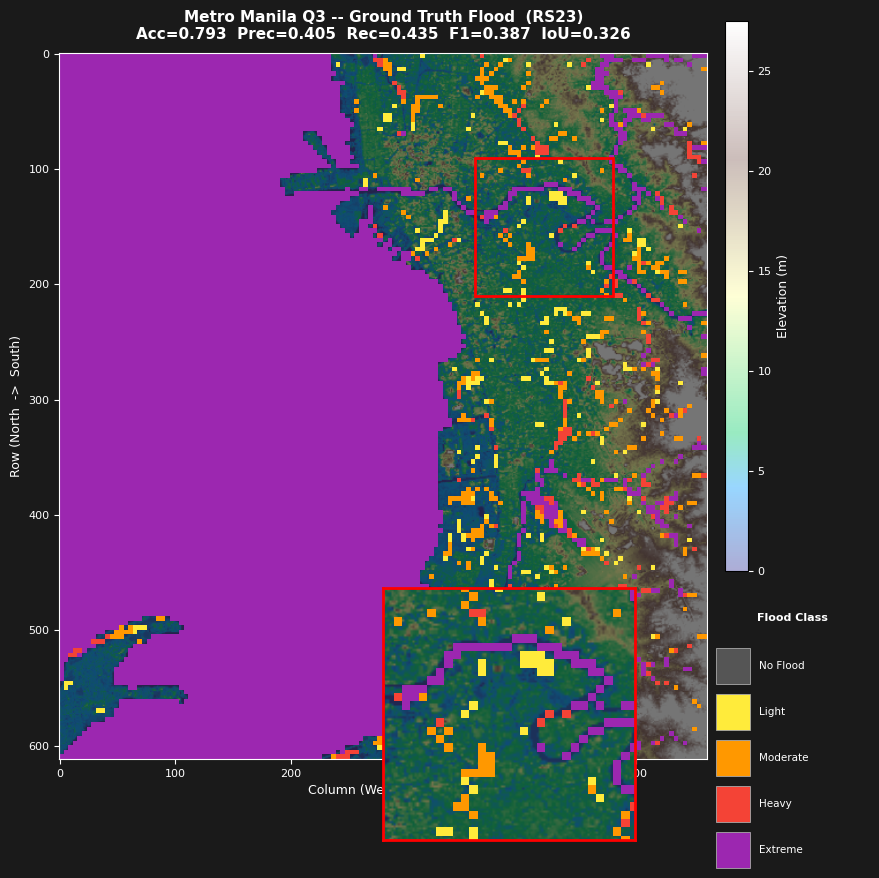


All figures saved.
  Best  scenario: RS23
  Worst scenario: RS2


In [27]:
H_dem, W_dem = dem_clean.shape
dem_q3 = dem_clean[H_dem//2:, :W_dem//2]   

best_idx  = results['aggregate']['best_scenario']  - 1
worst_idx = results['aggregate']['worst_scenario'] - 1

# Single scenario — predicted
fig4 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig4.savefig("eval_dem_best_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig5 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig5.savefig("eval_dem_best_gt.png", dpi=150, bbox_inches='tight')

plt.show()
print("\nAll figures saved.")
print(f"  Best  scenario: RS{results['aggregate']['best_scenario']}")
print(f"  Worst scenario: RS{results['aggregate']['worst_scenario']}")

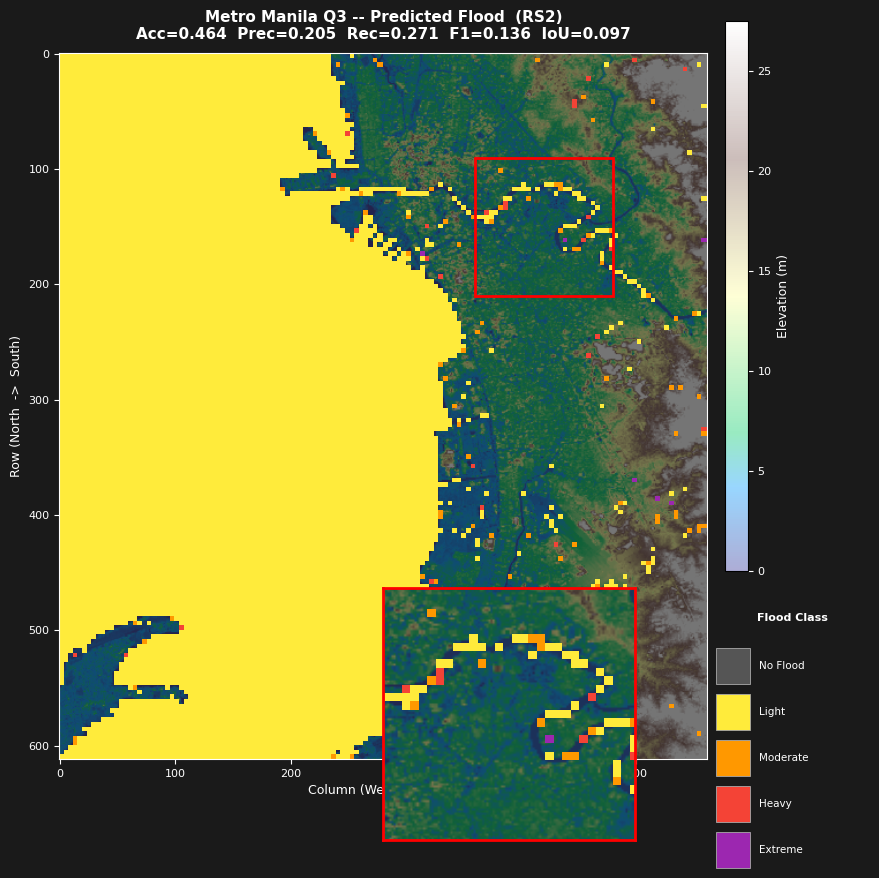

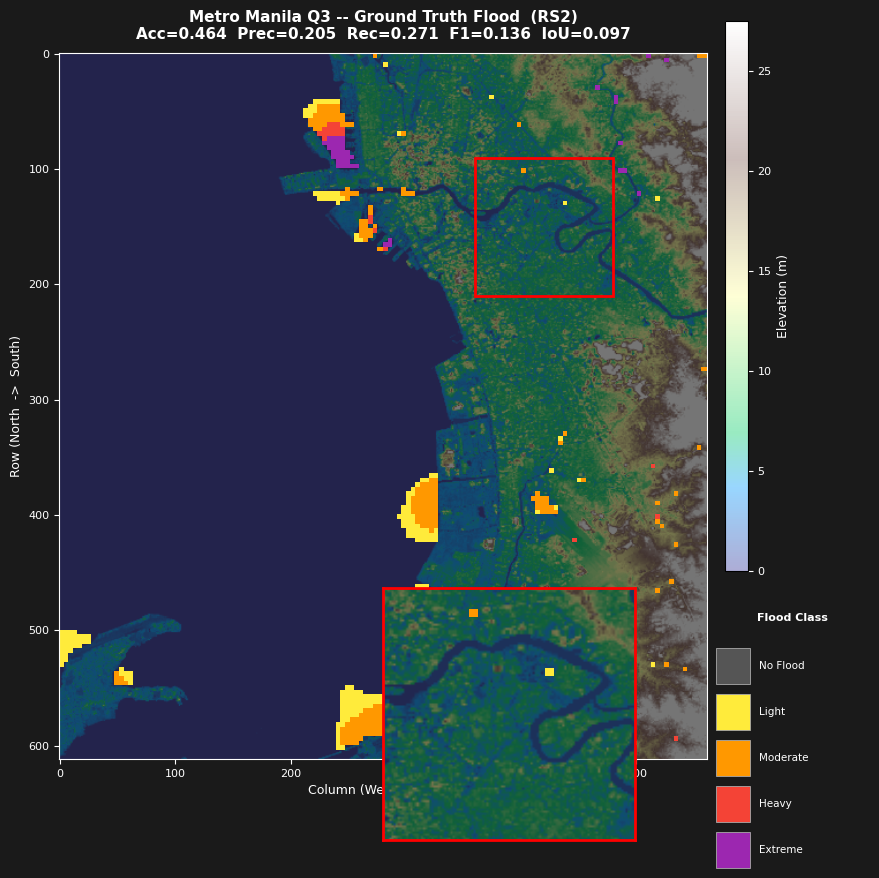

In [28]:
fig6 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][worst_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig6.savefig("eval_dem_worst_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig7 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][worst_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig7.savefig("eval_dem_worst_gt.png", dpi=150, bbox_inches='tight')

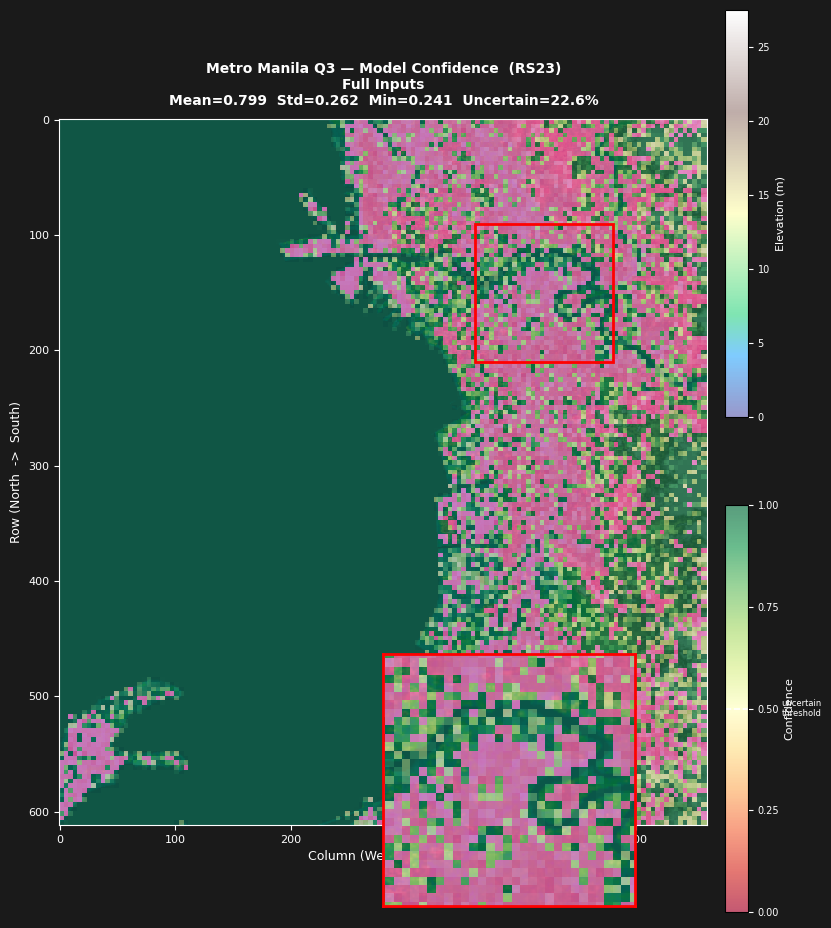

In [29]:
from testing import plot_confidence_on_dem

best_idx  = results['aggregate']['best_scenario']  - 1

fig_conf = plot_confidence_on_dem(
    dem_q3       = dem_q3,
    conf_map     = results['conf_maps'][best_idx],
    scenario_id  = results['aggregate']['best_scenario'],
    config_label = 'Full Inputs',
    confs_flat   = results['per_scenario'][best_idx]['confs_flat'],
    inset_center = (150, 420),
    figsize      = (9, 11),
    inset_size   = 60,
)
fig_conf.savefig("eval_dem_best_confidence.png", dpi=150, bbox_inches='tight')
plt.show()

# Hyperparamater Tuning

In [30]:
import torch
import torch.nn as nn
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from copy import deepcopy
from sklearn.metrics import f1_score as sk_f1
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Callable
import json
from datetime import datetime
from config import Config, ModelConfig, TrainConfig
from model_config import make_model
from training import FloodPatchDataset, CombinedLoss, compute_class_weights, run_epoch


def get_device() -> torch.device:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}\n")
    return device


def compute_loss(model_output, targets, criterion):
    if isinstance(model_output, tuple):
        logits = model_output[0]
    else:
        logits = model_output
    
    targets = targets.long()
    loss = criterion(logits, targets)
    return loss


def objective(trial: optuna.Trial, full_dataset: FloodPatchDataset, y_train: np.ndarray, base_cfg: Config,
    fold_val_indices: List[Tuple[np.ndarray, np.ndarray]], device: torch.device, num_folds: int, num_epochs: int, mode: str) -> float:
    
    cfg = deepcopy(base_cfg)
    # Model architecture parameters
    cfg.model.embed_dim = trial.suggest_categorical('embed_dim', [128, 256, 384, 512])
    cfg.model.num_heads = trial.suggest_categorical('num_heads', [4, 8, 16])
    cfg.model.num_layers = trial.suggest_int('num_layers', 2, 6)
    cfg.model.mlp_ratio = trial.suggest_float('mlp_ratio', 1.0, 4.0,  step=0.5)
    cfg.model.dropout = trial.suggest_float('dropout', 0.0, 0.5, step=0.05)
    cfg.model.rainfall_hidden = trial.suggest_categorical('rainfall_hidden', [32, 64, 128, 256])
    # Training hyperparameters
    cfg.train.lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    cfg.train.weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    cfg.train.warmup_epochs = trial.suggest_int('warmup_epochs', 5, 20)
    # Loss function weights
    ce_weight = trial.suggest_float('ce_weight', 0.7, 1.0, step=0.05)
    dice_weight = 1.0 - ce_weight
    cfg.train.batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    
    try:
        fold_scores = []
        trial_metrics = []
        
        # K-FOLD CROSS-VALIDATION
        for fold_idx, (train_idx, val_idx) in enumerate(fold_val_indices[:num_folds]):
            print(f"  Fold {fold_idx + 1}/{num_folds}...", end='', flush=True)
            
            # Create train and validation subsets
            train_subset = Subset(full_dataset, train_idx)
            val_subset = Subset(full_dataset, val_idx)
            
            # Create data loaders
            train_loader = DataLoader(
                train_subset, 
                batch_size=cfg.train.batch_size, 
                shuffle=True, 
                num_workers=0, 
                pin_memory=device.type == 'cuda'
            )
            val_loader = DataLoader(
                val_subset, 
                batch_size=cfg.train.batch_size, 
                shuffle=False, 
                num_workers=0, 
                pin_memory=device.type == 'cuda'
            )
            
            # Initialize model
            model = make_model(cfg.model).to(device)
            
            # Compute class weights for this fold's training data
            fold_y = y_train.flatten()
            fold_y = fold_y[fold_y >= 0]
            class_weights = compute_class_weights(y_train).to(device)
            criterion = CombinedLoss(
                class_weights=class_weights,
                ce_weight=ce_weight,
                dice_weight=dice_weight
            )
            
            # Initialize optimizer
            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=cfg.train.lr,
                weight_decay=cfg.train.weight_decay,
                betas=cfg.train.betas
            )
            
            # Early stopping within fold
            best_val_f1 = 0.0
            patience = 3
            no_improve = 0
            best_state = None
            
            # FOLD TRAINING LOOP
            for epoch in range(num_epochs):
                # ──── Training Phase ────
                model.train()
                train_loss = 0.0
                train_correct = 0
                train_total = 0
                
                for batch_idx, (spatial, rainfall, labels) in enumerate(train_loader):
                    spatial = spatial.to(device)
                    rainfall = rainfall.to(device)
                    labels = labels.to(device).long()
                    
                    optimizer.zero_grad()
                    model_output = model(spatial, rainfall)
                    loss = compute_loss(model_output, labels, criterion)
                    
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    
                    train_loss += loss.item() * labels.size(0)
                    
                    # Track accuracy
                    if isinstance(model_output, tuple):
                        logits = model_output[0]
                    else:
                        logits = model_output
                    preds = logits.argmax(dim=1)
                    train_correct += (preds == labels).sum().item()
                    train_total += labels.size(0)
                
                train_loss = train_loss / train_total
                train_acc = train_correct / train_total
                
                # ──── Validation Phase ────
                model.eval()
                val_loss = 0.0
                val_preds = []
                val_targets = []
                val_correct = 0
                val_total = 0
                
                with torch.no_grad():
                    for spatial, rainfall, labels in val_loader:
                        spatial = spatial.to(device)
                        rainfall = rainfall.to(device)
                        labels = labels.to(device).long()
                        
                        model_output = model(spatial, rainfall)
                        loss = compute_loss(model_output, labels, criterion)
                        
                        if isinstance(model_output, tuple):
                            logits = model_output[0]
                        else:
                            logits = model_output
                        
                        preds = logits.argmax(dim=1)
                        val_loss += loss.item() * labels.size(0)
                        val_correct += (preds == labels).sum().item()
                        val_total += labels.size(0)
                        
                        val_preds.extend(preds.cpu().numpy())
                        val_targets.extend(labels.cpu().numpy())
                
                val_loss = val_loss / val_total
                val_acc = val_correct / val_total
                val_f1 = sk_f1(val_targets, val_preds, average='macro', zero_division=0)
                
                # Early stopping
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    best_state = deepcopy(model.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1
                
                if no_improve >= patience:
                    break
                
                trial.report(val_f1, step=fold_idx * num_epochs + epoch)
                
                # Optuna prunes if trial is clearly underperforming
                if trial.should_prune():
                    print(f" [PRUNED at epoch {epoch+1}]")
                    raise optuna.TrialPruned()
            
            fold_scores.append(best_val_f1)
            trial_metrics.append({
                'fold': fold_idx + 1,
                'f1': best_val_f1,
                'best_epoch': epoch + 1,
                'train_loss': train_loss,
                'val_loss': val_loss,
            })
            print(f" F1={best_val_f1:.4f} (epoch {epoch+1})")
        
        # Return mean F1 across all folds
        mean_f1 = np.mean(fold_scores)
        print(f"  → Trial mean F1: {mean_f1:.4f}")
        return mean_f1
        
    except optuna.TrialPruned:
        raise
    except Exception as e:
        print(f"\n  ✗ Trial failed: {str(e)}")
        import traceback
        traceback.print_exc()
        return 0.0

def run_hyperparameter_tuning(full_dataset: FloodPatchDataset, y_train: np.ndarray, base_cfg: Config, n_trials: int, mode: str, num_folds: int, num_epochs: int) -> optuna.Study:
    device = get_device()
    random_seed = 42
    
    # Set random seeds for reproducibility
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    
    # Prepare k-fold indices
    kfold = KFold(n_splits=base_cfg.train.num_folds, shuffle=True, random_state=random_seed)
    fold_val_indices = list(kfold.split(np.arange(full_dataset.N_patches)))
    
    # Configure Optuna
    sampler = TPESampler(seed=random_seed)
    pruner = MedianPruner(n_startup_trials=3, n_warmup_steps=2)
    
    study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
    
    # Print configuration
    print(f"HYPERPARAMETER TUNING: {mode.upper()} MODE")
    print(f"Trials:               {n_trials}")
    print(f"K-folds:              {num_folds} (per trial)")
    print(f"Epochs:               {num_epochs} (per fold)")
    print(f"Total samples:        {len(full_dataset):,}")
    print(f"Device:               {device}")
    print(f"Random seed:          {random_seed}")
    
    # Run optimization
    study.optimize(
        lambda trial: objective(trial,
            full_dataset,
            y_train,
            base_cfg,
            fold_val_indices,
            device,
            num_folds=num_folds,
            num_epochs=num_epochs,
            mode=mode
        ),
        n_trials=n_trials,
        show_progress_bar=True
    )
    
    # Print results
    print_optimization_results(study)
    return study

def print_optimization_results(study: optuna.Study) -> None:
    completed_count = 0
    pruned_count = 0
    
    for trial in study.trials:
        # Convert state to string - works with ANY Optuna version
        state_str = str(trial.state).lower()
        
        if 'complete' in state_str or 'finished' in state_str:
            completed_count += 1
        elif 'pruned' in state_str:
            pruned_count += 1
    
    print(f"Completed Trials:     {completed_count}")
    print(f"Pruned Trials:        {pruned_count}")

def get_best_config(study: optuna.Study, base_cfg: Config) -> Config:
    cfg = deepcopy(base_cfg)
    best_params = study.best_params
    # Update model parameters
    cfg.model.embed_dim = best_params['embed_dim']
    cfg.model.num_heads = best_params['num_heads']
    cfg.model.num_layers = best_params['num_layers']
    cfg.model.mlp_ratio = best_params['mlp_ratio']
    cfg.model.dropout = best_params['dropout']
    cfg.model.rainfall_hidden = best_params['rainfall_hidden']
    # Update training parameters
    cfg.train.lr = best_params['lr']
    cfg.train.weight_decay = best_params['weight_decay']
    cfg.train.warmup_epochs = best_params['warmup_epochs']
    cfg.train.batch_size = best_params['batch_size']
    
    return cfg


c:\Users\CENSER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
from config import Config
config = Config()

study = run_hyperparameter_tuning(
    full_dataset    = train_dataset,              
    y_train         = dataset['y_train'],        
    base_cfg        = config,
    n_trials        = 10,
    mode            = 'fast',
    num_folds       = config.train.num_folds,
    num_epochs      = config.train.num_epochs
)

for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Get best config
best_config = get_best_config(study, config)
print(f"\n✓ Best F1 Score: {study.best_value:.4f}")

[I 2026-03-11 15:02:47,995] A new study created in memory with name: no-name-24991674-e5da-4ca0-ba49-68337580f4b4


Device: cuda

HYPERPARAMETER TUNING: FAST MODE
Trials:               10
K-folds:              2 (per trial)
Epochs:               20 (per fold)
Total samples:        3,228,300
Device:               cuda
Random seed:          42


  0%|          | 0/10 [00:00<?, ?it/s]

  Fold 1/2... F1=0.4659 (epoch 10)
  Fold 2/2...

Best trial: 0. Best value: 0.465275:  10%|█         | 1/10 [00:55<08:16, 55.18s/it]

...

 F1=0.5245 (epoch 8)
  → Trial mean F1: 0.5226
[I 2026-03-11 15:21:35,952] Trial 7 finished with value: 0.5226370456681251 and parameters: {'embed_dim': 512, 'num_heads': 16, 'num_layers': 6, 'mlp_ratio': 1.5, 'dropout': 0.35000000000000003, 'rainfall_hidden': 32, 'lr': 0.00018391267498288997, 'weight_decay': 0.00018495216589727275, 'warmup_epochs': 13, 'ce_weight': 0.7, 'batch_size': 64}. Best is trial 3 with value: 0.6608452266233511.
  Fold 1/2... F1=0.4588 (epoch 5)
  Fold 2/2...

Best trial: 3. Best value: 0.660845:  90%|█████████ | 9/10 [20:00<02:17, 137.92s/it]

 F1=0.4545 (epoch 4)
  → Trial mean F1: 0.4566
[I 2026-03-11 15:22:48,904] Trial 8 finished with value: 0.45663482271983236 and parameters: {'embed_dim': 384, 'num_heads': 16, 'num_layers': 2, 'mlp_ratio': 3.0, 'dropout': 0.2, 'rainfall_hidden': 32, 'lr': 0.0007069476197217987, 'weight_decay': 0.000568432246221227, 'warmup_epochs': 9, 'ce_weight': 0.8999999999999999, 'batch_size': 64}. Best is trial 3 with value: 0.6608452266233511.
  Fold 1/2...

Best trial: 3. Best value: 0.660845: 100%|██████████| 10/10 [21:34<00:00, 129.46s/it]

 [PRUNED at epoch 5]
[I 2026-03-11 15:24:22,624] Trial 9 pruned. 
Completed Trials:     6
Pruned Trials:        4
  embed_dim: 384
  num_heads: 16
  num_layers: 5
  mlp_ratio: 1.5
  dropout: 0.0
  rainfall_hidden: 32
  lr: 1.4063366777718176e-05
  weight_decay: 5.211124595788268e-05
  warmup_epochs: 6
  ce_weight: 1.0
  batch_size: 64

✓ Best F1 Score: 0.6608


In [32]:
# Create logs directory
logs_dir = cfg.train.output_ped_dir / 'logs'
logs_dir.mkdir(parents=True, exist_ok=True)

# Create best params dictionary
best_params_dict = {
    **study.best_params,
    'best_f1': float(study.best_value),
    'best_trial': int(study.best_trial.number),
    'total_trials': len(study.trials)
}

# Save to JSON
best_params_json = logs_dir / 'best_hyperparams.json'
with open(best_params_json, 'w') as f:
    json.dump(best_params_dict, f, indent=2)
print(f"✓ Saved best hyperparameters to JSON:")
print(f"  {best_params_json}")

# Save all trials to JSON
all_trials_json = logs_dir / 'all_trials.json'
all_trials_dict = {
    'num_trials': len(study.trials),
    'trials': []
}

for trial in study.trials:
    trial_dict = {
        'number': trial.number,
        'state': str(trial.state),
        'value': float(trial.value) if trial.value is not None else None,
        'params': trial.params,
    }
    all_trials_dict['trials'].append(trial_dict)

with open(all_trials_json, 'w') as f:
    json.dump(all_trials_dict, f, indent=2)
print(f"✓ Saved all {len(study.trials)} trial results to JSON:")
print(f"  {all_trials_json}")


# ========== APPLY BEST HYPERPARAMETERS ==========
print("\n" + "="*70)
print("APPLYING BEST HYPERPARAMETERS TO CONFIG")
print("="*70)

final_cfg = deepcopy(cfg)

# Apply to model config
final_cfg.model.embed_dim = study.best_params['embed_dim']
final_cfg.model.num_heads = study.best_params['num_heads']
final_cfg.model.num_layers = study.best_params['num_layers']
final_cfg.model.mlp_ratio = study.best_params['mlp_ratio']
final_cfg.model.dropout = study.best_params['dropout']
final_cfg.model.rainfall_hidden = study.best_params['rainfall_hidden']

# Apply to training config
final_cfg.train.lr = study.best_params['lr']
final_cfg.train.weight_decay = study.best_params['weight_decay']
final_cfg.train.warmup_epochs = study.best_params['warmup_epochs']
final_cfg.train.ce_weight = study.best_params['ce_weight']
final_cfg.train.batch_size = study.best_params['batch_size']


print("\n✓ Config updated with best hyperparameters:")
print(f"  embed_dim: {final_cfg.model.embed_dim}")
print(f"  num_heads: {final_cfg.model.num_heads}")
print(f"  num_layers: {final_cfg.model.num_layers}")
print(f"  mlp_ratio: {final_cfg.model.mlp_ratio}")
print(f"  dropout: {final_cfg.model.dropout}")
print(f"  rainfall_hidden: {final_cfg.model.rainfall_hidden}")
print(f"  lr: {final_cfg.train.lr}")
print(f"  weight_decay: {final_cfg.train.weight_decay}")
print(f"  ce_weight: {final_cfg.train.ce_weight}")
print(f"  batch_size: {final_cfg.train.batch_size}")


# Save updated config to JSON
config_json = logs_dir / 'config_with_best_hyperparams.json'
final_cfg.save(config_json)
print(f"\n✓ Saved updated config to:")
print(f"  {config_json}")



✓ Saved best hyperparameters to JSON:
  checkpoints_ped\logs\best_hyperparams.json
✓ Saved all 10 trial results to JSON:
  checkpoints_ped\logs\all_trials.json

APPLYING BEST HYPERPARAMETERS TO CONFIG

✓ Config updated with best hyperparameters:
  embed_dim: 384
  num_heads: 16
  num_layers: 5
  mlp_ratio: 1.5
  dropout: 0.0
  rainfall_hidden: 32
  lr: 1.4063366777718176e-05
  weight_decay: 5.211124595788268e-05
  ce_weight: 1.0
  batch_size: 64

✓ Saved updated config to:
  checkpoints_ped\logs\config_with_best_hyperparams.json


In [ ]:
print(f"\nTraining final model with best hyperparameters...")
print(f"Best F1 from tuning: {study.best_value:.4f}\n")

fold_histories, best_fold = train_kfold(
    model_factory      = lambda: make_model(final_cfg.model), 
    full_dataset       = train_dataset,                              
    y_train            = dataset['y_train'],        
    cfg                = final_cfg.train,
    device             = device,
    checkpoint_dir     = final_cfg.train.output_ped_dir,
)

print(f"\n✓ Final model training complete!")
print(f"  Best fold: {best_fold + 1}")



Training final model with best hyperparameters...
Best F1 from tuning: 0.6608


FOLD 1 / 2
  Train samples : 1,614,150
  Val   samples : 1,614,150
    [TRAIN] batch  1000/25222  loss=1.6907  acc=0.4860
    [TRAIN] batch  2000/25222  loss=1.6909  acc=0.4882
    [TRAIN] batch  3000/25222  loss=1.6904  acc=0.4891
    [TRAIN] batch  4000/25222  loss=1.6905  acc=0.4893
    [TRAIN] batch  5000/25222  loss=1.6905  acc=0.4894
    [TRAIN] batch  6000/25222  loss=1.6906  acc=0.4902
    [TRAIN] batch  7000/25222  loss=1.6906  acc=0.4905
    [TRAIN] batch  8000/25222  loss=1.6905  acc=0.4904
    [TRAIN] batch  9000/25222  loss=1.6905  acc=0.4903
    [TRAIN] batch 10000/25222  loss=1.6906  acc=0.4903
    [TRAIN] batch 11000/25222  loss=1.6907  acc=0.4903
    [TRAIN] batch 12000/25222  loss=1.6905  acc=0.4906
    [TRAIN] batch 13000/25222  loss=1.6905  acc=0.4906
    [TRAIN] batch 14000/25222  loss=1.6905  acc=0.4909
    [TRAIN] batch 15000/25222  loss=1.6906  acc=0.4908
    [TRAIN] batch 16000/252

ValueError: Unknown format code 'f' for object of type 'str'

In [46]:
# ========== EVALUATE ON TEST SET ==========
print("\nLoading best model from final training...")
model_path = final_cfg.train.output_ped_dir / f'fold_{best_fold + 1}' / 'best_model.pt'
ckpt = torch.load(model_path, map_location=device) 

final_model = make_model(final_cfg.model) 
final_model.load_state_dict(ckpt['model_state_dict'])
final_model.to(device)
final_model.eval()

# ========== PREPARE TEST EVALUATION ==========
print("\nPreparing ground truth maps for test scenarios...")
ground_truth = prepare_ground_truth(
    y_test           = dataset['y_test'],     
    quadrant_indices = quadrant_indices,
    patch_metadata   = patch_metadata[0],
)

print("\nEvaluating final model on test scenarios...")
results_tuned  = evaluate_all_scenarios(
    model           = final_model,
    X_test          = dataset['X_test'],
    y_test          = dataset['y_test'],
    conditioning_vectors = conditioning_vectors,
    ground_truth    = ground_truth,
    batch_size      = final_cfg.train.batch_size,
    device          = device,
    num_classes     = final_cfg.model.num_classes,
)



Loading best model from final training...

Preparing ground truth maps for test scenarios...

Preparing ground truth maps for test scenarios...
  Q3 patch grid : 153 rows × 140 cols = 21420 patches
  GT maps shape : (50, 153, 140)  ✓

Evaluating final model on test scenarios...

Evaluating all test scenarios...
  RS01  Acc=0.5257  Prec=0.2527  Rec=0.2856  F1=0.2237  IoU=0.1585  Conf=0.617  Uncertain=57.4%
  RS02  Acc=0.4750  Prec=0.2112  Rec=0.2706  F1=0.1410  IoU=0.1014  Conf=0.715  Uncertain=51.5%
  RS03  Acc=0.5263  Prec=0.2561  Rec=0.2880  F1=0.2227  IoU=0.1584  Conf=0.614  Uncertain=55.7%
  RS04  Acc=0.5186  Prec=0.2603  Rec=0.2791  F1=0.2301  IoU=0.1602  Conf=0.617  Uncertain=12.0%
  RS05  Acc=0.4765  Prec=0.2662  Rec=0.2948  F1=0.1859  IoU=0.1314  Conf=0.613  Uncertain=51.7%
  RS06  Acc=0.5262  Prec=0.2560  Rec=0.2890  F1=0.2224  IoU=0.1583  Conf=0.613  Uncertain=55.3%
  RS07  Acc=0.4926  Prec=0.2565  Rec=0.2974  F1=0.1850  IoU=0.1262  Conf=0.683  Uncertain=51.5%
  RS08  Acc=0.

In [47]:
import json

new_inference_config = {
    "patch_size":       final_cfg.model.patch_size,
    "num_classes":      final_cfg.model.num_classes,
    "in_channels":      final_cfg.model.in_channels,
    "conditioning_dim": final_cfg.model.conditioning_dim,
    "num_timesteps":    final_cfg.model.num_timesteps,
    "rainfall_method":  final_cfg.model.rainfall_method,

    "embed_dim":        study.best_params['embed_dim'],     
    "num_heads":        study.best_params['num_heads'],      
    "num_layers":       study.best_params['num_layers'],
    "mlp_ratio":        study.best_params['mlp_ratio'],
    "dropout":          study.best_params['dropout'],
    "rainfall_hidden":  study.best_params['rainfall_hidden'],
    "learnable_pos_enc": final_cfg.model.learnable_pos_enc,
    "lr":               study.best_params['lr'],
    "weight_decay":     study.best_params['weight_decay'],
    "warmup_epochs":    study.best_params['warmup_epochs'],
    "ce_weight":        study.best_params['ce_weight'],    
    "batch_size":       study.best_params['batch_size'],
    "best_fold":        best_fold + 1,
    "checkpoint_dir":   str(final_cfg.train.output_ped_dir),
    "tuning_info": {
        "best_trial":     int(study.best_trial.number),
        "total_trials":   len(study.trials),
        "tuning_best_f1": float(study.best_value),
        "validation_f1":  float(ckpt['best_macro_f1']),
    },
}

inference_config_path = final_cfg.train.output_ped_dir / 'inference_config.json'
with open(inference_config_path, 'w') as f:
    json.dump(new_inference_config, f, indent=2)

In [ ]:
fig1 = plot_metrics_summary(results_tuned)
fig1.savefig("eval_metrics_summary.png", dpi=150, bbox_inches='tight')

fig2 = plot_per_scenario_metrics(results_tuned)
fig2.savefig("eval_per_scenario.png", dpi=150, bbox_inches='tight')

fig3 = plot_per_class_metrics(results_tuned)
fig3.savefig("eval_per_class.png", dpi=150, bbox_inches='tight')

plt.show()